<a href="https://colab.research.google.com/github/tgp989/airline-review-analytics/blob/main/Proyecto_final_Santiago_Giraldo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Proyecto final**

**Fecha de entrega:**  Lunes 26 de mayo

El proyecto se puede realizar en parejas o individual

Se debe buscar una base de datos de al menos 200 registros que contenga mensajes de la percepción de los usuarios con respecto al producto, servicio o empresa para hacer análisis de sentimientos. También se debe tener la información correspondiente de las personas que escribieron los mensajes, para poder hacer clustering y caracterización de los usuarios.

La base de datos puede estar disponible en internet, referenciándola apropiadamente. También puede ser una base de datos real de una empresa.
Los estudiantes tendrán la posibilidad de realizar encuestas para recolectar dicha información.


## Informe solicitado

Se espera un análisis que incluya lo siguiente:
1.   **```(60%)```** Creación de grupos homógeneos de los clientes en la base de datos. Reportando en cada grupo como es el sentimiento de los consumidores con respecto al producto, servicio o empresa seleccionada.
2.   **```(50%)```** Análisis y clasificación de las opiniones de los clientes con respecto a la satisfacción de los clientes en general con respecto al producto, servicio o empresa seleccionada.
  *   Nivel de satisfacción del cliente.
  *   Razón principal por la que está satisfecho o insatisfecho.
  *   Caracterización de la satisfacción de los clientes por otras variables.

## Nota
*   **No se permiten trabajos utilizando la misma base de datos**
*   **Uso de inteligencia artificial limitado**: el uso de inteligencia artificial es permitido, pero debe ser limitado, que se observe que el estudiante se apoya en ella, mas no que es un trabajo en su gran mayoría realizado por una inteligencia artificial.

---




# Rúbrica de evaluación

## Creación de grupos homógeneos (60%)

1.	Preprocesamiento de los datos (40%)
  *   Limpieza de los datos (25%)
  *   Transformación y creación de variables (15%)
2.	Exploración preliminar de los datos (10%)
  *   Gráficos de visualización
  *   Descripción de los hallazgos preliminares
3.	Desarrollo de modelos (25%)
  *   Selección de variables
  *   Preparación de variables
  *   Modelos analizados
  *   Modelo seleccionado y su justificación
  *   Presentación de los hallazgos
4.	Modelo entrenado guardado listo para asignar nuevas observaciones (10%)
5.	Informe ejecutivo de resultados (25%)

## Análisis y clasificación de la satisfacción de los clientes (50%)

1.	Procesamiento de los mensajes y creación de niveles de satisfacción (35%)
2.	Razón principal por la que está satisfecho o insatisfecho con su banco (25%)
3.	Informe ejecutivo de resultados (40%)

# Creación de grupos homógeneos

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering, KMeans, DBSCAN

from scipy.cluster.hierarchy import dendrogram, linkage

In [ ]:
path= "/content/drive/MyDrive/Colab aprendizaje no supervisado/Proyecto final/BA_AirlineReviews.csv" # Colocar la ubicación del archivo
data= pd.read_csv(path) # Creamos el dataframe con los datos
data.head()

,Unnamed: 0,OverallRating,ReviewHeader,Name,Datetime,VerifiedReview,ReviewBody,TypeOfTraveller,SeatType,Route,DateFlown,SeatComfort,CabinStaffService,GroundService,ValueForMoney,Recommended,Aircraft,Food&Beverages,InflightEntertainment,Wifi&Connectivity
0,0,1.0,"""Service level far worse then Ryanair""",L Keele,19th November 2023,True,4 Hours before takeoff we received a Mail stat...,Couple Leisure,Economy Class,London to Stuttgart,November 2023,1.0,1.0,1.0,1.0,no,NaN,NaN,NaN,NaN
1,1,3.0,"""do not upgrade members based on status""",Austin Jones,19th November 2023,True,I recently had a delay on British Airways from...,Business,Economy Class,Brussels to London,November 2023,2.0,3.0,1.0,2.0,no,A320,1.0,2.0,2.0
2,2,8.0,"""Flight was smooth and quick""",M A Collie,16th November 2023,False,"Boarded on time, but it took ages to get to th...",Couple Leisure,Business Class,London Heathrow to Dublin,November 2023,3.0,3.0,4.0,3.0,yes,A320,4.0,NaN,NaN
3,3,1.0,"""Absolutely hopeless airline""",Nigel Dean,16th November 2023,True,"5 days before the flight, we were advised by B...",Couple Leisure,Economy Class,London to Dublin,December 2022,3.0,3.0,1.0,1.0,no,NaN,NaN,NaN,NaN
4,4,1.0,"""Customer Service is non existent""",Gaylynne Simpson,14th November 2023,False,"We traveled to Lisbon for our dream vacation, ...",Couple Leisure,Economy Class,London to Lisbon,November 2023,1.0,1.0,1.0,1.0,no,NaN,1.0,1.0,1.0


## Limpieza de datos

In [ ]:
data.shape

(3701, 20)

In [ ]:
# Eliminar columnas innecesarias
data = data.drop(columns=['Name','ReviewHeader'])
data.head()

,Unnamed: 0,OverallRating,Datetime,VerifiedReview,ReviewBody,TypeOfTraveller,SeatType,Route,DateFlown,SeatComfort,CabinStaffService,GroundService,ValueForMoney,Recommended,Aircraft,Food&Beverages,InflightEntertainment,Wifi&Connectivity
0,0,1.0,19th November 2023,True,4 Hours before takeoff we received a Mail stat...,Couple Leisure,Economy Class,London to Stuttgart,November 2023,1.0,1.0,1.0,1.0,no,NaN,NaN,NaN,NaN
1,1,3.0,19th November 2023,True,I recently had a delay on British Airways from...,Business,Economy Class,Brussels to London,November 2023,2.0,3.0,1.0,2.0,no,A320,1.0,2.0,2.0
2,2,8.0,16th November 2023,False,"Boarded on time, but it took ages to get to th...",Couple Leisure,Business Class,London Heathrow to Dublin,November 2023,3.0,3.0,4.0,3.0,yes,A320,4.0,NaN,NaN
3,3,1.0,16th November 2023,True,"5 days before the flight, we were advised by B...",Couple Leisure,Economy Class,London to Dublin,December 2022,3.0,3.0,1.0,1.0,no,NaN,NaN,NaN,NaN
4,4,1.0,14th November 2023,False,"We traveled to Lisbon for our dream vacation, ...",Couple Leisure,Economy Class,London to Lisbon,November 2023,1.0,1.0,1.0,1.0,no,NaN,1.0,1.0,1.0


In [ ]:
print("Datos nulos por columna:")
print(data.isnull().sum())
print("\n")
print("Número total de datos nulos:")
print(data.isnull().sum().sum())
data_cleaned = data.dropna()
print("\nDimensiones del dataframe después de eliminar filas con valores nulos:")
data_cleaned.shape

Datos nulos por columna:
Unnamed: 0                  0
OverallRating               5
Datetime                    0
VerifiedReview              0
ReviewBody                  0
TypeOfTraveller           771
SeatType                    2
Route                     775
DateFlown                 778
SeatComfort               116
CabinStaffService         127
GroundService             846
ValueForMoney               1
Recommended                 0
Aircraft                 1779
Food&Beverages            386
InflightEntertainment    1150
Wifi&Connectivity        3092
dtype: int64


Número total de datos nulos:
9828

Dimensiones del dataframe después de eliminar filas con valores nulos:


(327, 18)

In [ ]:
print("Datos nulos por columna:")
print(data_cleaned.isnull().sum())

Datos nulos por columna:
Unnamed: 0               0
OverallRating            0
Datetime                 0
VerifiedReview           0
ReviewBody               0
TypeOfTraveller          0
SeatType                 0
Route                    0
DateFlown                0
SeatComfort              0
CabinStaffService        0
GroundService            0
ValueForMoney            0
Recommended              0
Aircraft                 0
Food&Beverages           0
InflightEntertainment    0
Wifi&Connectivity        0
dtype: int64



Visualizando datos atípicos con Box Plots:


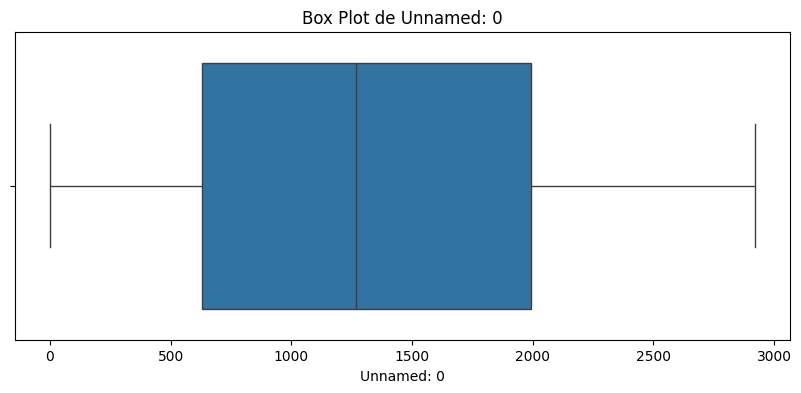

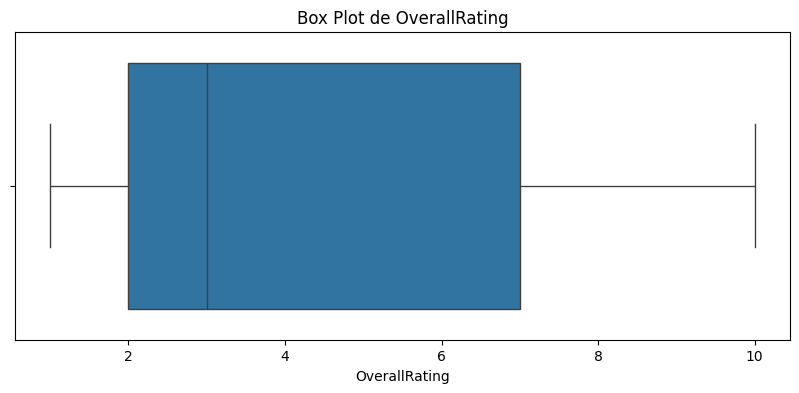

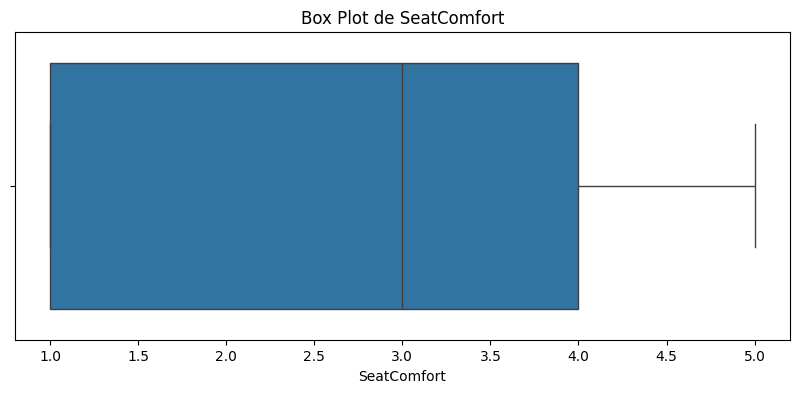

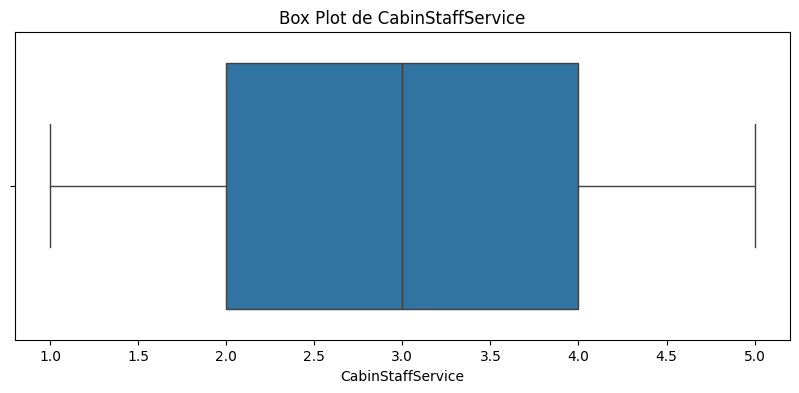

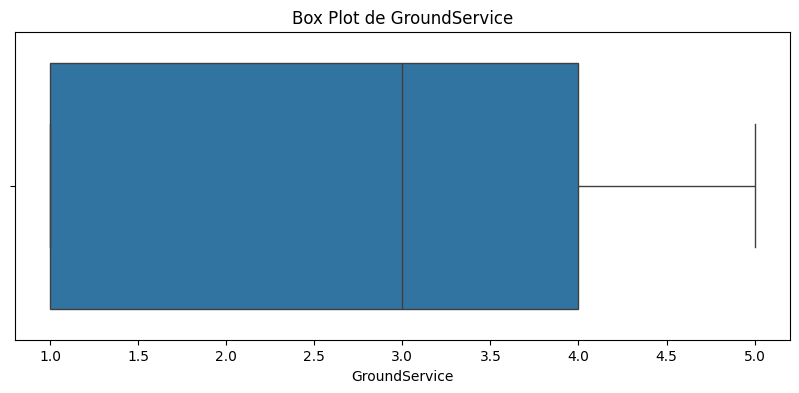

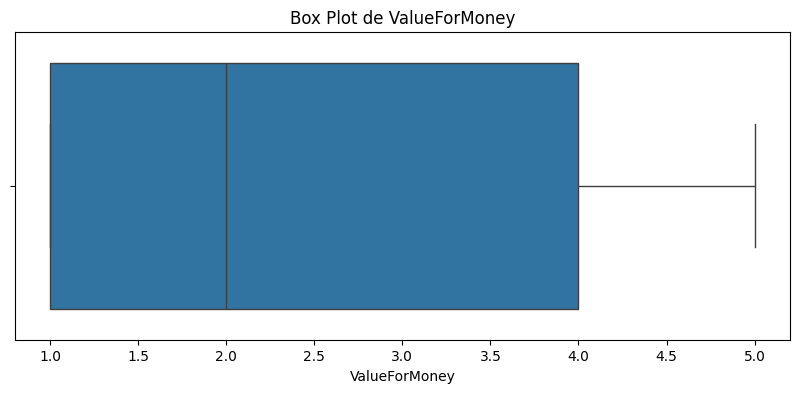

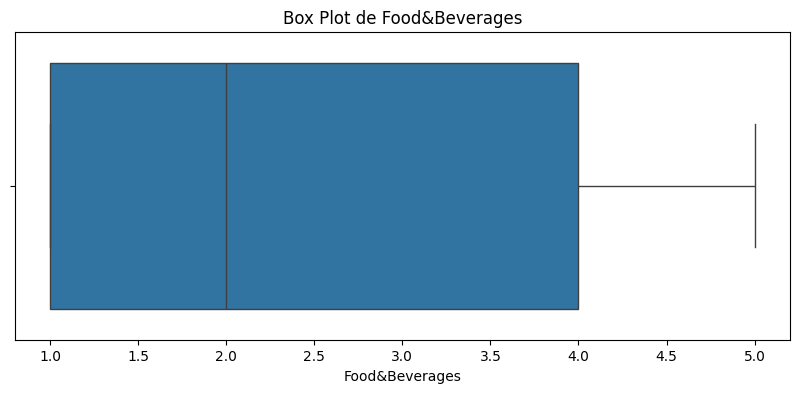

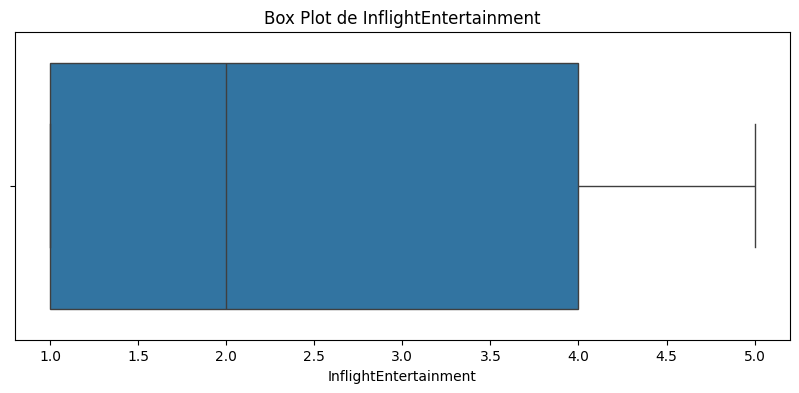

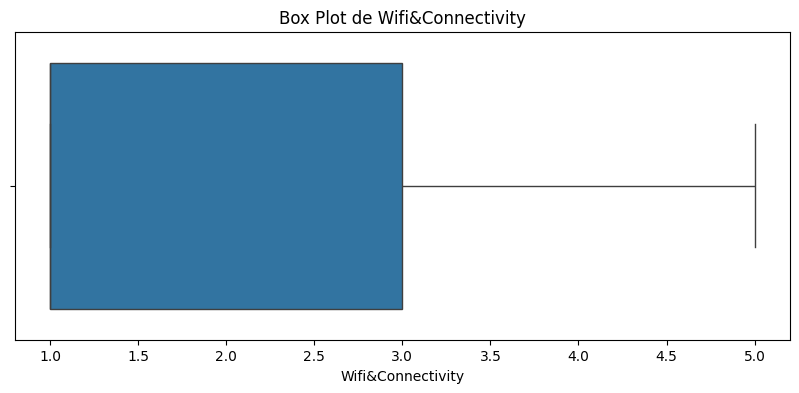


Detectando posibles datos atípicos usando el método IQR:
Columna: Unnamed: 0
  Número de posibles atípicos detectados por IQR: 0
------------------------------
Columna: OverallRating
  Número de posibles atípicos detectados por IQR: 0
------------------------------
Columna: SeatComfort
  Número de posibles atípicos detectados por IQR: 0
------------------------------
Columna: CabinStaffService
  Número de posibles atípicos detectados por IQR: 0
------------------------------
Columna: GroundService
  Número de posibles atípicos detectados por IQR: 0
------------------------------
Columna: ValueForMoney
  Número de posibles atípicos detectados por IQR: 0
------------------------------
Columna: Food&Beverages
  Número de posibles atípicos detectados por IQR: 0
------------------------------
Columna: InflightEntertainment
  Número de posibles atípicos detectados por IQR: 0
------------------------------
Columna: Wifi&Connectivity
  Número de posibles atípicos detectados por IQR: 0
-------

In [ ]:
# Detectar datos atípicos usando gráficos de caja (box plots)
# Seleccionar columnas numéricas para el análisis de atípicos
numeric_cols = data_cleaned.select_dtypes(include=np.number).columns

if len(numeric_cols) > 0:
    print("\nVisualizando datos atípicos con Box Plots:")
    # Crear box plots para cada columna numérica
    for col in numeric_cols:
        plt.figure(figsize=(10, 4))
        sns.boxplot(x=data_cleaned[col])
        plt.title(f'Box Plot de {col}')
        plt.show()
else:
    print("\nNo hay columnas numéricas en el dataframe 'cleaned' para verificar datos atípicos.")

# Opcional: Detectar atípicos usando el método IQR
print("\nDetectando posibles datos atípicos usando el método IQR:")
for col in numeric_cols:
    Q1 = data_cleaned[col].quantile(0.25)
    Q3 = data_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data_cleaned[(data_cleaned[col] < lower_bound) | (data_cleaned[col] > upper_bound)]

    print(f"Columna: {col}")
    print(f"  Número de posibles atípicos detectados por IQR: {len(outliers)}")
    if len(outliers) > 0:
        print(f"  Ejemplo de atípicos:\n{outliers[[col]].head()}")
    print("-" * 30)

In [ ]:
data_cleaned.head()

,Unnamed: 0,OverallRating,Datetime,VerifiedReview,ReviewBody,TypeOfTraveller,SeatType,Route,DateFlown,SeatComfort,CabinStaffService,GroundService,ValueForMoney,Recommended,Aircraft,Food&Beverages,InflightEntertainment,Wifi&Connectivity
1,1,3.0,19th November 2023,True,I recently had a delay on British Airways from...,Business,Economy Class,Brussels to London,November 2023,2.0,3.0,1.0,2.0,no,A320,1.0,2.0,2.0
8,8,2.0,5th November 2023,False,"Angry, disappointed, and unsatisfied. My route...",Family Leisure,Economy Class,London Heatrow to Atlanta,November 2023,4.0,5.0,3.0,5.0,yes,Boeing 777,4.0,4.0,3.0
25,25,5.0,14th October 2023,True,I am a frequent flyer with BA and have been fo...,Business,Business Class,London to Istanbul,October 2023,3.0,4.0,3.0,2.0,no,A320,1.0,1.0,1.0
33,33,10.0,7th October 2023,True,"Excellent service levels, proactive crew and s...",Solo Leisure,First Class,London to New York JFK,October 2023,5.0,5.0,5.0,5.0,yes,Boeing 777,5.0,4.0,5.0
34,34,1.0,5th October 2023,False,Booked a very special holiday for me and my pa...,Couple Leisure,Business Class,Heathrow to Marseille,August 2023,1.0,1.0,1.0,1.0,no,BA366,1.0,1.0,1.0


Se eliminaron las filas con datos vacíos y no hay datos atípicos registrados en el dataframe

## Transformación y creación de variables

In [ ]:
data_cleaned['Route'].value_counts()

,count
Route,
Chicago to London Heathrow,6
London to New York JFK,4
Vancouver to London,4
London to Johannesburg,4
LHR to BKK,4
...,...
LHR to LAX,1
Chicago to Paris via London,1
LCY to JFK via Shannon,1


In [ ]:
# Split the 'Route' column and ensure we get exactly two columns
split_route = data_cleaned['Route'].str.split(' to ', expand=True)

# Assign the first two resulting columns to 'From' and 'To'
# Use .iloc[:, :2] to select the first two columns generated by the split
data_cleaned[['From', 'To']] = split_route.iloc[:, :2]

# Drop the original 'Route' column
data_cleaned = data_cleaned.drop(columns=['Route'])

<ipython-input-12-add2e99b840d>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned[['From', 'To']] = split_route.iloc[:, :2]
<ipython-input-12-add2e99b840d>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned[['From', 'To']] = split_route.iloc[:, :2]


In [ ]:
data_cleaned['From'].value_counts()

,count
From,
London,78
LHR,33
London Heathrow,26
Gatwick,11
Heathrow,8
...,...
CPH,1
Punta Cana,1
DFW,1


In [ ]:
data_cleaned['To'].value_counts()

,count
To,
London,46
LHR,28
London Heathrow,23
Johannesburg,6
New York JFK,6
...,...
Faro,1
LAX,1
JFK via Shannon,1


In [ ]:
data_cleaned.head()

,Unnamed: 0,OverallRating,Datetime,VerifiedReview,ReviewBody,TypeOfTraveller,SeatType,DateFlown,SeatComfort,CabinStaffService,GroundService,ValueForMoney,Recommended,Aircraft,Food&Beverages,InflightEntertainment,Wifi&Connectivity,From,To
1,1,3.0,19th November 2023,True,I recently had a delay on British Airways from...,Business,Economy Class,November 2023,2.0,3.0,1.0,2.0,no,A320,1.0,2.0,2.0,Brussels,London
8,8,2.0,5th November 2023,False,"Angry, disappointed, and unsatisfied. My route...",Family Leisure,Economy Class,November 2023,4.0,5.0,3.0,5.0,yes,Boeing 777,4.0,4.0,3.0,London Heatrow,Atlanta
25,25,5.0,14th October 2023,True,I am a frequent flyer with BA and have been fo...,Business,Business Class,October 2023,3.0,4.0,3.0,2.0,no,A320,1.0,1.0,1.0,London,Istanbul
33,33,10.0,7th October 2023,True,"Excellent service levels, proactive crew and s...",Solo Leisure,First Class,October 2023,5.0,5.0,5.0,5.0,yes,Boeing 777,5.0,4.0,5.0,London,New York JFK
34,34,1.0,5th October 2023,False,Booked a very special holiday for me and my pa...,Couple Leisure,Business Class,August 2023,1.0,1.0,1.0,1.0,no,BA366,1.0,1.0,1.0,Heathrow,Marseille


## Gráficos de visualización

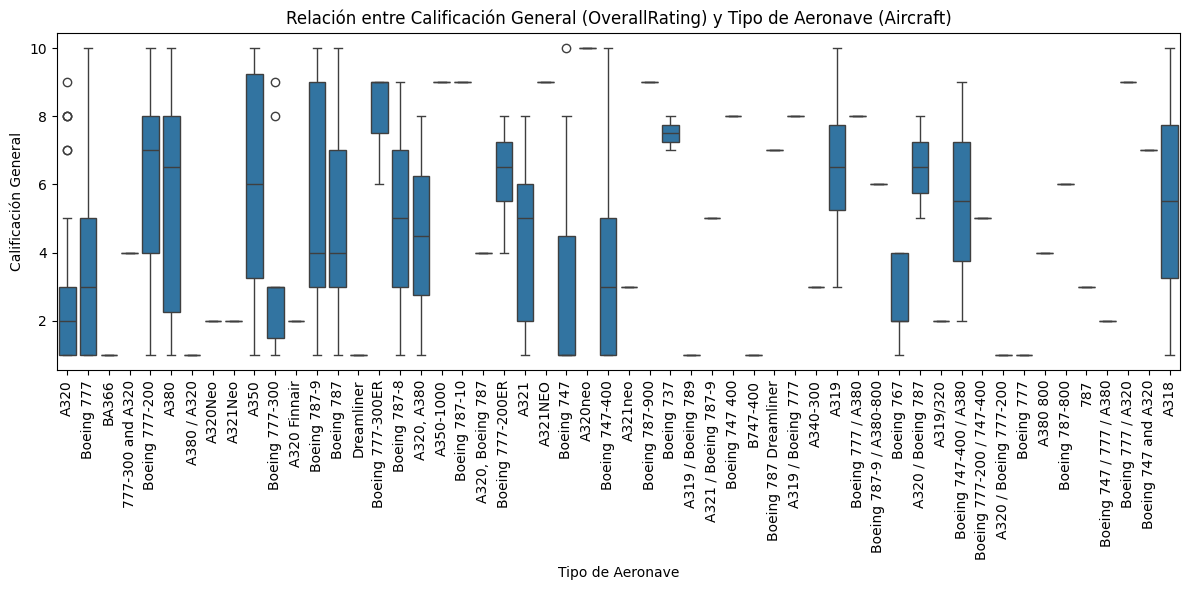

In [ ]:

plt.figure(figsize=(12, 6))
sns.boxplot(x='Aircraft', y='OverallRating', data=data_cleaned)
plt.title('Relación entre Calificación General (OverallRating) y Tipo de Aeronave (Aircraft)')
plt.xlabel('Tipo de Aeronave')
plt.ylabel('Calificación General')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

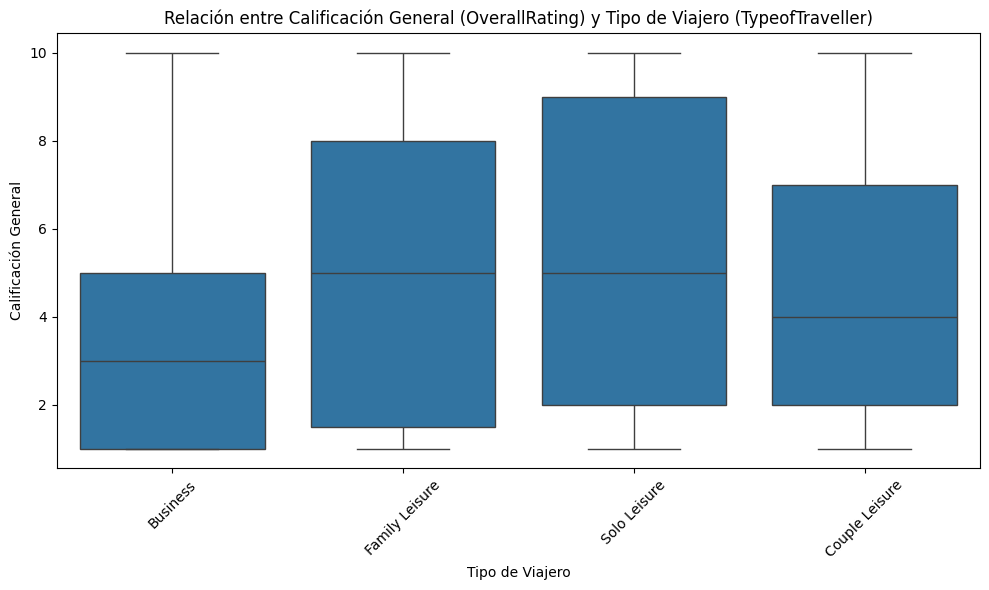

In [ ]:

plt.figure(figsize=(10, 6))
sns.boxplot(x='TypeOfTraveller', y='OverallRating', data=data_cleaned)
plt.title('Relación entre Calificación General (OverallRating) y Tipo de Viajero (TypeofTraveller)')
plt.xlabel('Tipo de Viajero')
plt.ylabel('Calificación General')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

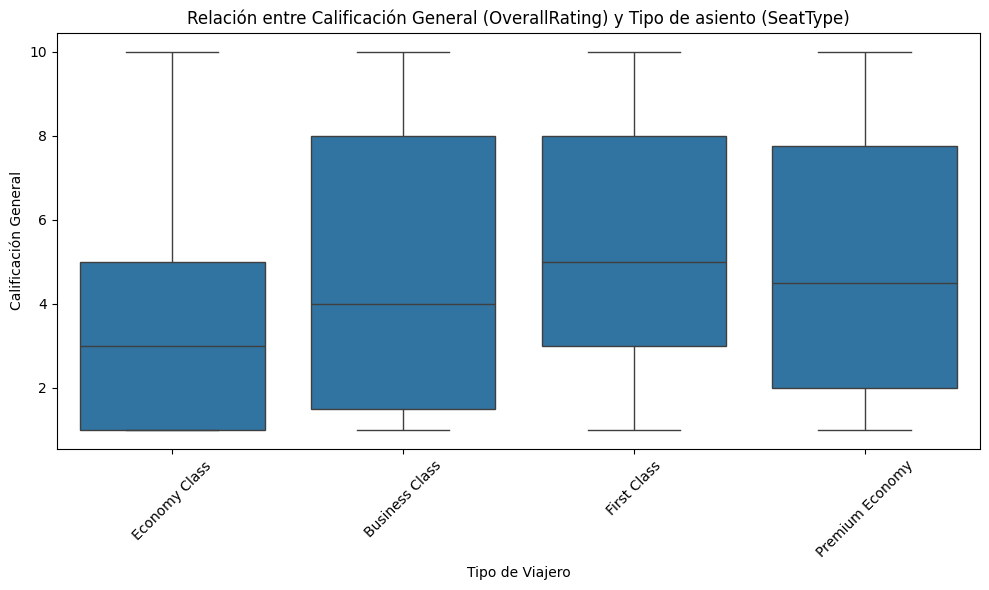

In [ ]:

plt.figure(figsize=(10, 6))
sns.boxplot(x='SeatType', y='OverallRating', data=data_cleaned)
plt.title('Relación entre Calificación General (OverallRating) y Tipo de asiento (SeatType)')
plt.xlabel('Tipo de Viajero')
plt.ylabel('Calificación General')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

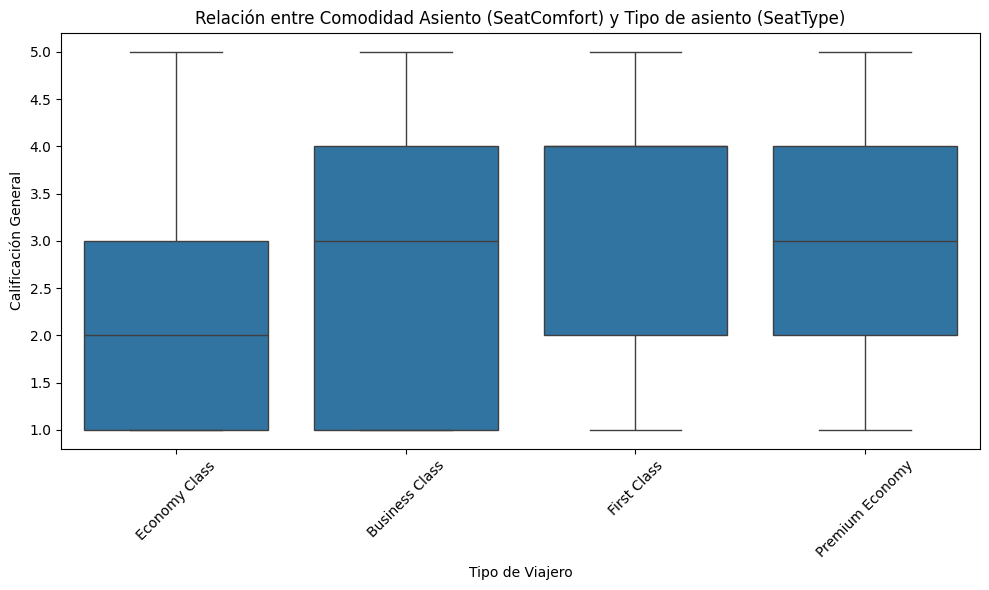

In [ ]:

plt.figure(figsize=(10, 6))
sns.boxplot(x='SeatType', y='SeatComfort', data=data_cleaned)
plt.title('Relación entre Comodidad Asiento (SeatComfort) y Tipo de asiento (SeatType)')
plt.xlabel('Tipo de Viajero')
plt.ylabel('Calificación General')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

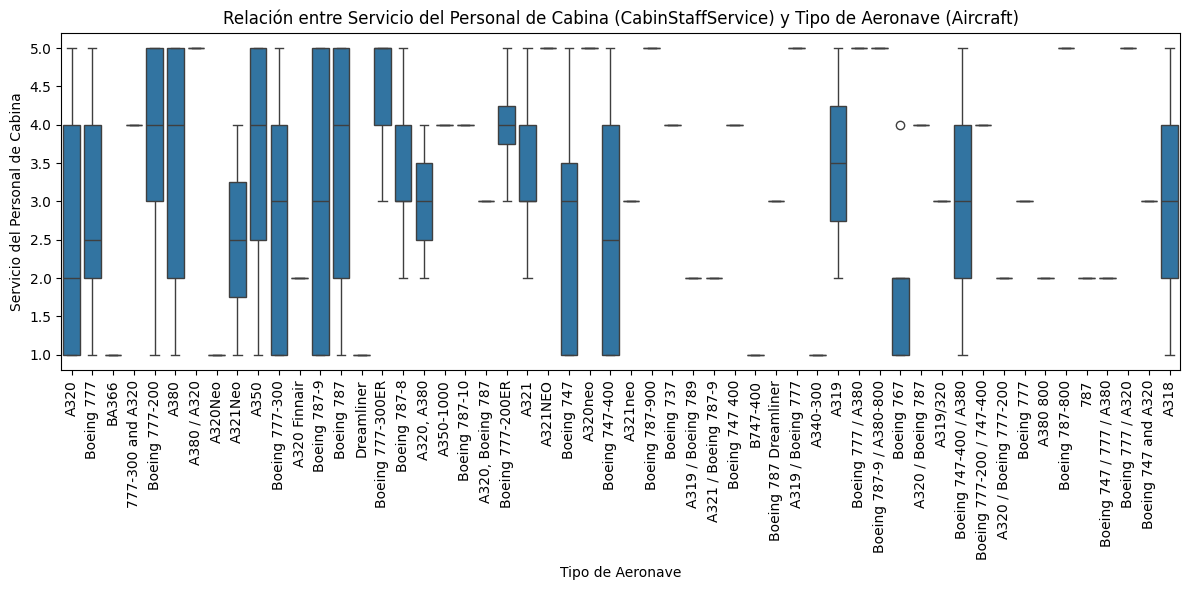

In [ ]:

plt.figure(figsize=(12, 6))
sns.boxplot(x='Aircraft', y='CabinStaffService', data=data_cleaned)
plt.title('Relación entre Servicio del Personal de Cabina (CabinStaffService) y Tipo de Aeronave (Aircraft)')
plt.xlabel('Tipo de Aeronave')
plt.ylabel('Servicio del Personal de Cabina')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

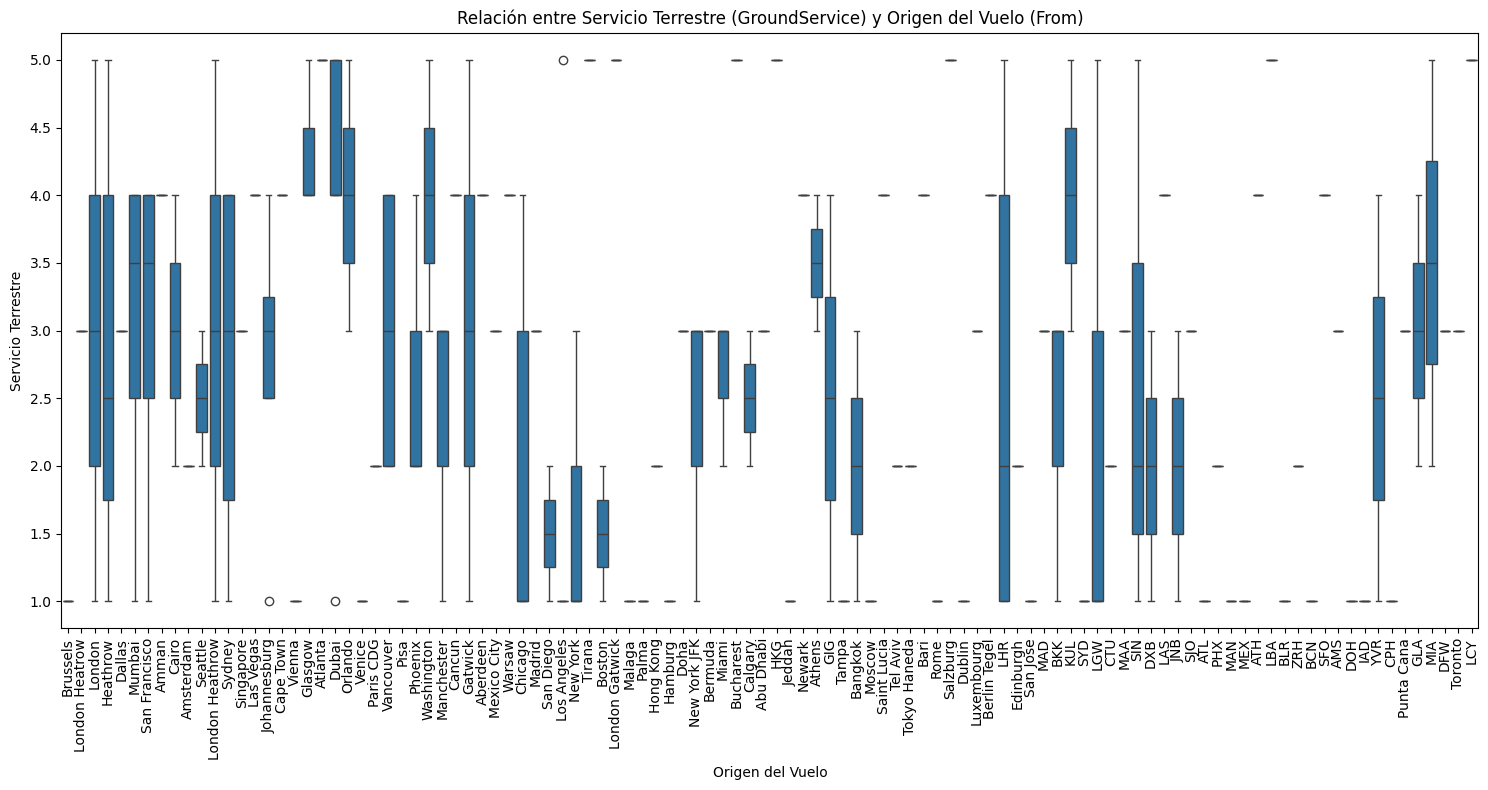

In [ ]:

plt.figure(figsize=(15, 8))
sns.boxplot(x='From', y='GroundService', data=data_cleaned)
plt.title('Relación entre Servicio Terrestre (GroundService) y Origen del Vuelo (From)')
plt.xlabel('Origen del Vuelo')
plt.ylabel('Servicio Terrestre')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

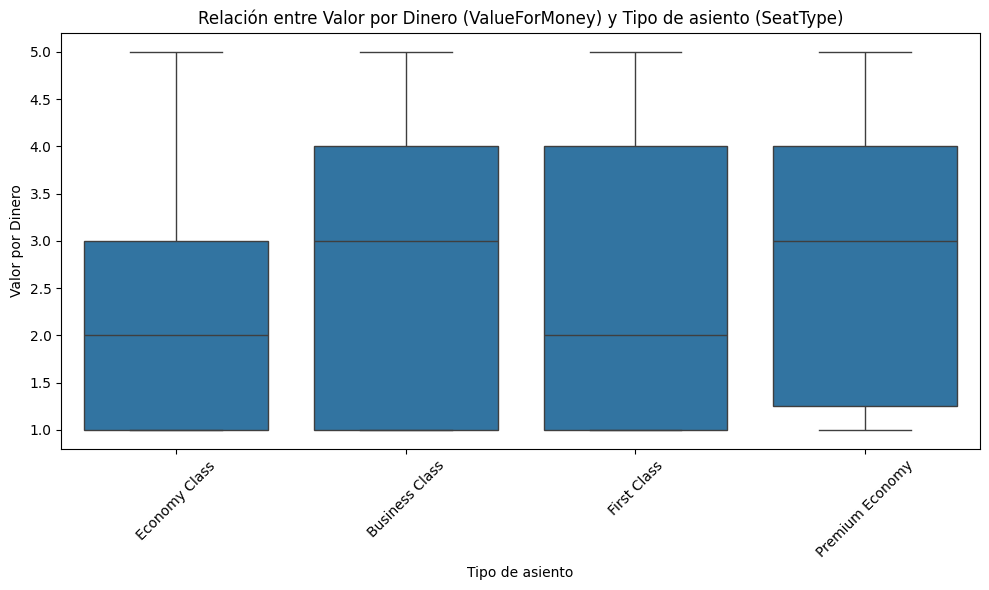

In [ ]:

plt.figure(figsize=(10, 6))
sns.boxplot(x='SeatType', y='ValueForMoney', data=data_cleaned)
plt.title('Relación entre Valor por Dinero (ValueForMoney) y Tipo de asiento (SeatType)')
plt.xlabel('Tipo de asiento')
plt.ylabel('Valor por Dinero')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

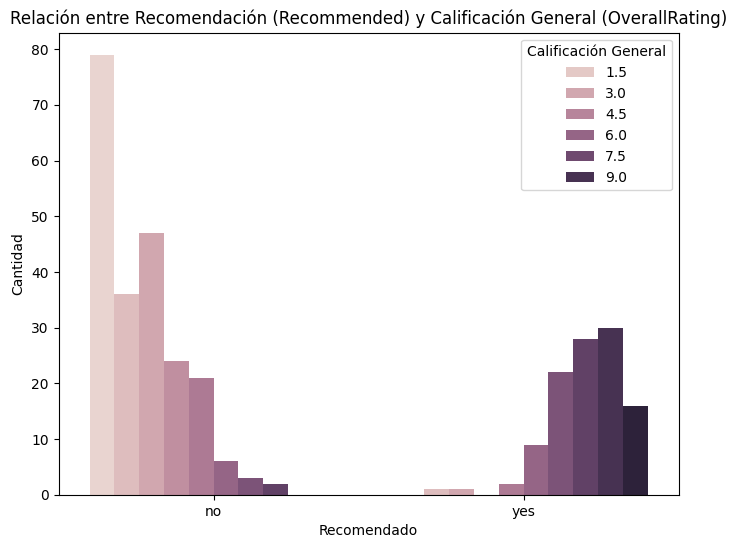

In [ ]:

plt.figure(figsize=(8, 6))
sns.countplot(x='Recommended', hue='OverallRating', data=data_cleaned)
plt.title('Relación entre Recomendación (Recommended) y Calificación General (OverallRating)')
plt.xlabel('Recomendado')
plt.ylabel('Cantidad')
plt.legend(title='Calificación General')
plt.show()

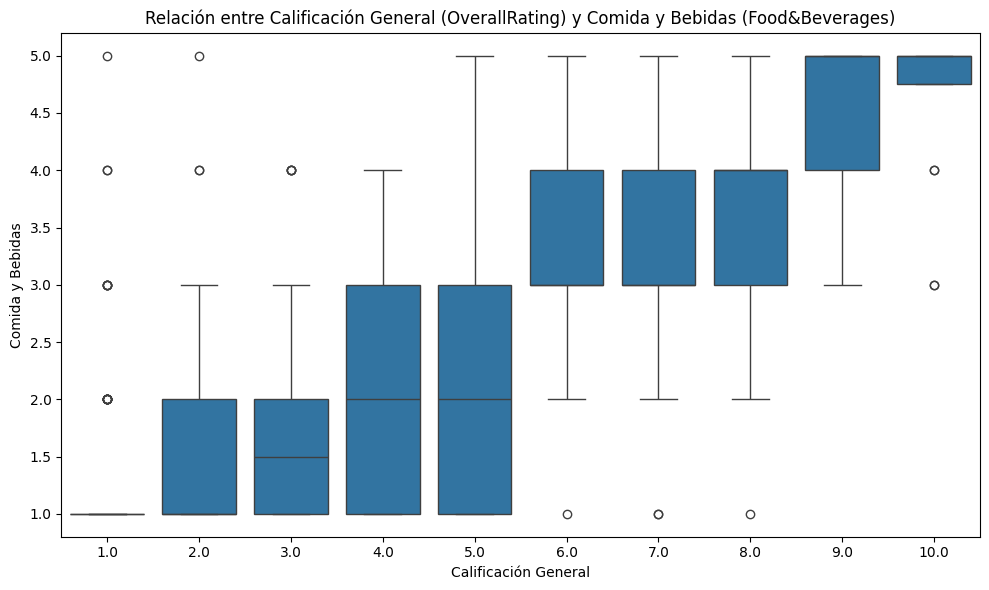

In [ ]:

plt.figure(figsize=(10, 6))
sns.boxplot(x='OverallRating', y='Food&Beverages', data=data_cleaned)
plt.title('Relación entre Calificación General (OverallRating) y Comida y Bebidas (Food&Beverages)')
plt.xlabel('Calificación General')
plt.ylabel('Comida y Bebidas')
plt.tight_layout()
plt.show()


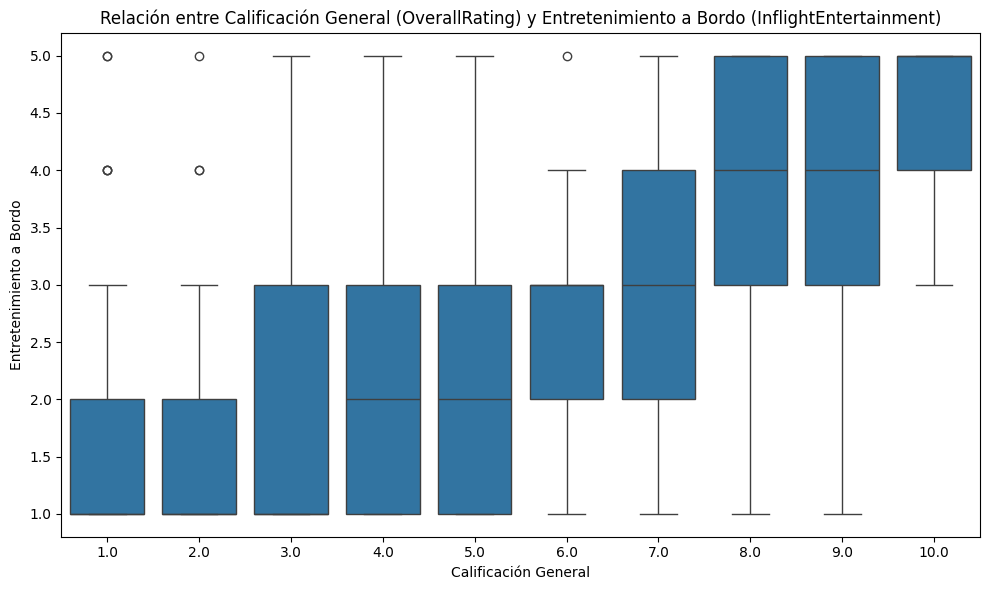

In [ ]:

plt.figure(figsize=(10, 6))
sns.boxplot(x='OverallRating', y='InflightEntertainment', data=data_cleaned)
plt.title('Relación entre Calificación General (OverallRating) y Entretenimiento a Bordo (InflightEntertainment)')
plt.xlabel('Calificación General')
plt.ylabel('Entretenimiento a Bordo')
plt.tight_layout()
plt.show()

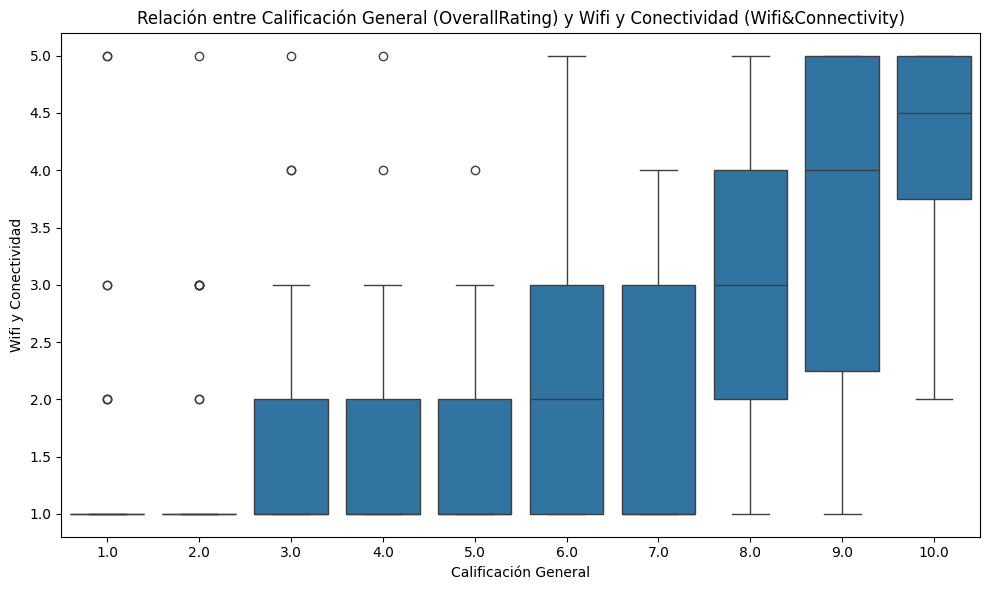

In [ ]:

plt.figure(figsize=(10, 6))
sns.boxplot(x='OverallRating', y='Wifi&Connectivity', data=data_cleaned)
plt.title('Relación entre Calificación General (OverallRating) y Wifi y Conectividad (Wifi&Connectivity)')
plt.xlabel('Calificación General')
plt.ylabel('Wifi y Conectividad')
plt.tight_layout()
plt.show()

## Descripción de hallazgos

## Overall Rating vs Aircraft:
La mayoría de las aeronaves tienen calificaciones que varían de 2 a 10, con algunas excepciones que presentan calificaciones por debajo de 2.

Los modelos de aeronaves como el Boeing 787 y el Airbus A350 muestran un rango superior en las calificaciones, evidenciando mejores puntuaciones generales.

La variabilidad en las calificaciones es notable; por ejemplo, el Boeing 777 y el Airbus A320 muestran una amplia distribución, lo que indica diferencias significativas en las experiencias de los usuarios.

Algunos modelos, como el Boeing 737 y el A320, tienen un rango de calificaciones más estrecho, lo que sugiere una satisfacción más consistente entre los usuarios.

## Overall Rating vs Type Of Traveller:
**Business:**

Exhibe la calificación más baja.

La mediana se sitúa cerca de 3.

Amplio rango intercuartílico (IQR), lo que indica variabilidad en las calificaciones.

**Family Leisure:**

La calificación promedio es más alta, con una mediana alrededor de 9.

Menor variabilidad comparada con "Business".

**Solo Leisure:**

Mediana alrededor de 8.

IQR similar al de “Family Leisure”, mostrando una calificación consistente.

**Couple Leisure:**

Promedio de calificación relativamente alto, semejante al de "Solo Leisure", con una mediana aproximada a 8.

La distribución muestra una variabilidad, pero no tan amplia como en "Business".

## Overall Rating vs Seat Type:

Existe una tendencia clara en que las clases superiores (Business, First, Premium Economy) reciben calificaciones significativamente más altas que la clase económica.

Las puntuaciones de las clases superiores son más consistentes y menos variables, sugiriendo una mejor experiencia percibida entre los pasajeros que optan por estas opciones.

La clase económica tiene la mayor variabilidad en sus calificaciones, posiblemente indicando experiencias más desiguales entre los pasajeros.

## Seat Comfort vs Seat Type:

**Economy Class:**

La calificación general es la más baja en comparación con las otras clases, con un rango entre aproximadamente 1.5 y 3.5.

**Business Class:**

Muestra una calificación mayor que Economy, con un rango que parece estar entre 2.5 y 4.0, indicando una mejor comodidad.

**First Class:**

Esta categoría recibe la calificación más alta, con un rango de aproximadamente 3.5 a 4.5.

**Premium Economy:**

Las calificaciones son intermedias, con un rango que también se encuentra alrededor de 3.0 a 4.0, sugiriendo que es un poco más cómoda que Economy pero no tan buena como Business o First Class.

## Aircraft vs Cabin Staff Service:

Algunos modelos, como el Boeing 777 y Airbus A350, tienden a tener puntuaciones más altas en el servicio, indicando una mejor experiencia para los pasajeros en estos aviones.

Otros, como el Boeing 747 o ciertos modelos de Airbus, muestran puntuaciones más bajas, sugiriendo áreas de mejora en el servicio.

Existe una considerable variabilidad en las puntuaciones del servicio entre diferentes tipos de aeronaves, reflejada en la longitud de los "bigotes" en el boxplot.

## Ground Service vs From:

La calidad del "Servicio Terrestre" varía significativamente dependiendo del origen del vuelo.

Es importante considerar detalles como los puntos atípicos y la distribución de las puntuaciones individuales para mejorar la calidad del servicio en ciertas áreas.

## Seat Type vs Value For Money:

**Media del Valor por Dinero:**

La clase Economy muestra la media más baja (alrededor de 2.0).

La clase Business y First Class tienen medias más altas (alrededor de 3.5), indicando un mejor valor percibido.

Premium Economy también muestra un valor intermedio.

**Rango y Dispersión:**

Las cajas indican el rango intercuartílico, mostrando cómo se distribuyen los valores.

Economy tiene una dispersión menor comparada con otras clases, mientras que Business y Premium Economy tienen rangos más amplios.

**Comparaciones:**

Business Class y First Class tienen boxes más altos y más amplios, sugiriendo que los pasajeros perciben un mayor valor por su dinero en estas categorías.

Economy Class presenta la menor satisfacción en términos de valor por dinero.

## Recommended vs Overall Rating:

**Categoría "no":**

Predomina un número elevado de respuestas con calificaciones bajas (1.5, 3.0).

Hay una disminución en la cantidad a medida que se incrementan las calificaciones, destacando una escasez de recomendaciones "no" con calificaciones superiores a 6.0.

**Categoría "yes":**

Muestra una distribución más equilibrada con un aumento notable en las calificaciones más altas (6.0, 7.5, 9.0).

La mayoría de las recomendaciones "sí" se agrupan en torno a las calificaciones de 6.0 y superiores, sugiriendo una fuerte correlación entre recomendar y recibir calificaciones altas.

**Conclusiones:**

Existe una clara relación entre las recomendaciones y las calificaciones generales.

Las personas que no recomiendan el producto/servicio tienden a otorgar calificaciones más bajas.

En contraste, aquellas que sí recomiendan tienen una tendencia significativa a dar calificaciones altas.

## Overall Rating vs Food & Beverages:

**Tendencia Positiva:**

A medida que aumenta la calificación general, la calificación de comida y bebidas también tiende a aumentar.

**Rango de Calificaciones:**

Las calificaciones de comida y bebidas en las calificaciones generales más bajas (1-2) son notablemente más bajas (promedio entre 1.5 y 3).

**Dispersión:**

Hay presencia de valores atípicos (puntos fuera de las cajas) en casi todas las calificaciones, especialmente en las calificaciones generales más altas.

**Cajas Más Altas:**

Las cajas representan la mediana y el rango intercuartílico, donde se observa
que las calificaciones de comida y bebida son consistentemente más altas a partir de una calificación general de 4.

## Overall Rating vs Inflight Enterteinment:

**Tendencia General:**

A medida que la calificación general aumenta, también lo hace el puntaje del entretenimiento a bordo. Se observa una tendencia positiva.

**Distribución de Datos:**

Cada caja representa la intercuartil (IQ) de los datos, donde:
* La línea dentro de la caja indica la mediana.
* Los extremos de la caja representan el primer y tercer cuartil.
* Las "líneas" que se extienden (bigotes) indican el rango de datos fuera de los cuartiles.

**Valores Atípicos:**

Existen algunos puntos fuera de los bigotes en varias calificaciones generales, lo que sugiere la presencia de valores atípicos. Estos podrían representar casos donde el entretenimiento a bordo fue particularmente alto, pero el cúmulo de las variables disminuyó la calificación general.

**Comparación entre Categorías:**

La diferencia entre los resultados de entretenimiento a bordo es notable entre las calificaciones. En general, las calificaciones más bajas (1 a 4) muestran valores de entretenimiento menores, mientras que las calificaciones más altas (6 a 10) muestran un aumento en el entretenimiento a bordo.

**Rango de Puntajes:**

La mayoría de los puntajes de entretenimiento a bordo se concentran en un rango relativamente estrecho, pero aumentan con las calificaciones generales. Esto sugiere que los usuarios están más satisfechos con el entretenimiento en vuelos mejor calificados.

## Overall Rating vs Wifi & Connectivity:

**Tendencia general positiva:**

En los tres gráficos se observa una tendencia clara: a medida que la Calificación General aumenta (de 1 a 10), también tiende a aumentar la mediana y el rango de la Wifi y Conectividad. Esto indica que los usuarios que dan calificaciones generales más altas suelen tener una mejor percepción del wifi y conectividad.

**Aumento de la variabilidad con calificación:**

Los rangos intercuartílicos (cajas) y los valores atípicos aumentan a medida que la Calificación General sube. Esto sugiere que, aunque en promedio hay mejor wifi y conectividad en calificaciones más altas, la percepción de esta variable es más variable. Es decir, usuarios con calificación general alta pueden tener tanto experiencias muy buenas como malas con el wifi.

**Distribución inicial sesgada:**

Para calificaciones generales bajas (1 a 4), la mayoría de las observaciones se concentran cerca del valor mínimo de Wifi y Conectividad (mediana cercana a 1). Esto implica que una mala percepción general suele estar acompañada de una mala experiencia de conectividad.

**Valores atípicos en calificaciones bajas:**

Se aprecian muchos valores atípicos hacia arriba en calificaciones bajas (1-4), lo que podría indicar que, aunque la mayoría tiene malas experiencias de wifi, hay casos donde las personas tuvieron una buena conectividad pero dieron una baja calificación general por otros factores.

**Calificaciones altas con mejores valores de wifi:**

En las calificaciones de 7 a 10, la mediana y los cuartiles son mayores, lo que refleja que generalmente quienes otorgan buenas calificaciones también tienen percepciones positivas sobre el wifi.

## Selección de variables

In [ ]:
data_cleaned.columns # Para conocer el nombre de las columnas

Index(['Unnamed: 0', 'OverallRating', 'Datetime', 'VerifiedReview',
       'ReviewBody', 'TypeOfTraveller', 'SeatType', 'DateFlown', 'SeatComfort',
       'CabinStaffService', 'GroundService', 'ValueForMoney', 'Recommended',
       'Aircraft', 'Food&Beverages', 'InflightEntertainment',
       'Wifi&Connectivity', 'From', 'To'],
      dtype='object')

In [ ]:
data_cat=data_cleaned[['OverallRating','ValueForMoney','SeatComfort','CabinStaffService','Food&Beverages']]


In [ ]:
data_cat.head()

,OverallRating,ValueForMoney,SeatComfort,CabinStaffService,Food&Beverages
1,3.0,2.0,2.0,3.0,1.0
8,2.0,5.0,4.0,5.0,4.0
25,5.0,2.0,3.0,4.0,1.0
33,10.0,5.0,5.0,5.0,5.0
34,1.0,1.0,1.0,1.0,1.0


In [ ]:
corr_matrix = data_cat.corr()
corr_matrix

,OverallRating,ValueForMoney,SeatComfort,CabinStaffService,Food&Beverages
OverallRating,1.000000,0.852835,0.750210,0.722636,0.756909
ValueForMoney,0.852835,1.000000,0.707664,0.652691,0.685435
SeatComfort,0.750210,0.707664,1.000000,0.643542,0.671123
CabinStaffService,0.722636,0.652691,0.643542,1.000000,0.723704
Food&Beverages,0.756909,0.685435,0.671123,0.723704,1.000000


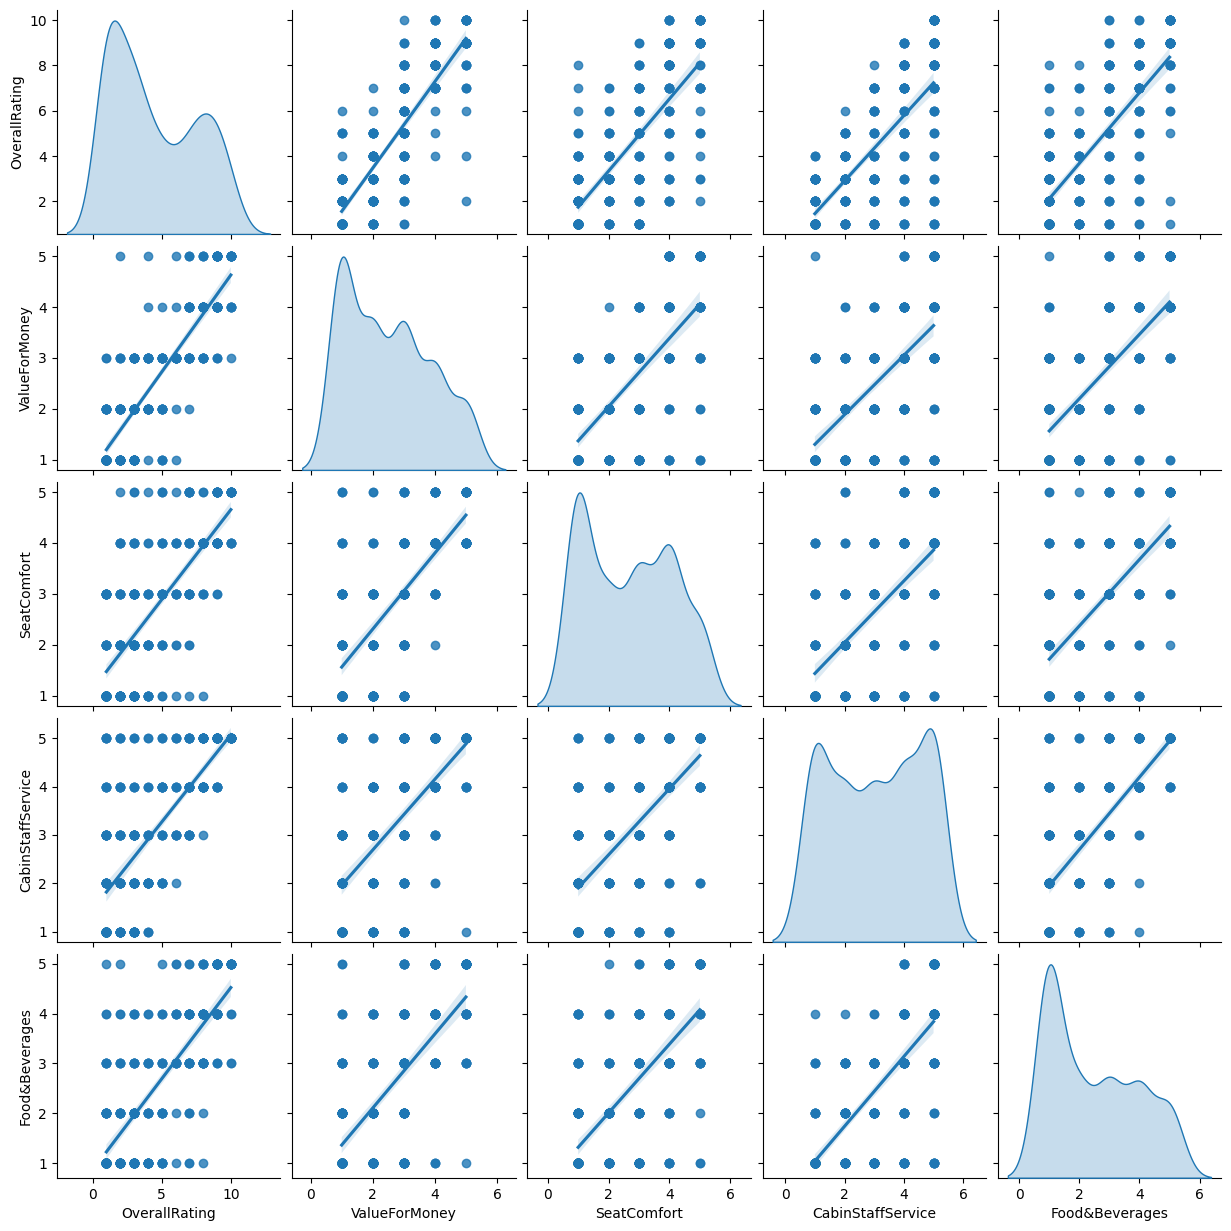

In [ ]:
sns.pairplot(data_cat, kind="reg", diag_kind="kde")
plt.show()

## Preparación de variables

In [ ]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(data_cat)
scaled_features

array([[-0.46917652, -0.37054834, -0.47885324, -0.03450953, -1.01068431],
       [-0.801256  ,  1.85956162,  0.93182253,  1.29309251,  1.04633085],
       [ 0.19498245, -0.37054834,  0.22648464,  0.62929149, -1.01068431],
       ...,
       [-1.13333548, -0.37054834, -1.18419113, -0.69831056, -1.01068431],
       [ 1.1912209 ,  1.85956162,  0.93182253,  1.29309251,  0.36065913],
       [-1.13333548, -1.11391833, -1.18419113, -0.03450953, -0.32501259]])

In [ ]:
est=pd.DataFrame(scaled_features, columns=data_cat.columns)
est

,OverallRating,ValueForMoney,SeatComfort,CabinStaffService,Food&Beverages
0,-0.469177,-0.370548,-0.478853,-0.034510,-1.010684
1,-0.801256,1.859562,0.931823,1.293093,1.046331
2,0.194982,-0.370548,0.226485,0.629291,-1.010684
3,1.855380,1.859562,1.637160,1.293093,1.732003
4,-1.133335,-1.113918,-1.184191,-1.362112,-1.010684
...,...,...,...,...,...
322,0.859141,1.116192,0.931823,1.293093,1.046331
323,1.855380,0.372822,1.637160,1.293093,1.732003
324,-1.133335,-0.370548,-1.184191,-0.698311,-1.010684
325,1.191221,1.859562,0.931823,1.293093,0.360659


## Modelo analizado (KMeans)

In [ ]:
kmeans = KMeans(
  init="random", # Este parámetro determina donde se ubican los centroides inicialmente
  n_clusters=3, # Corresponde al número de clusters que se van a crear
  n_init=10, # El número de veces que se iniciarán los centroides para seleccionar los mejores, según la inercia
  max_iter=300, # Número máximo de iteraciones para encontrar los clusters optimos
  random_state=42 # Este valor asegura que los resultados son reproducibles
  )

In [ ]:
kmeans.fit(scaled_features)

KMeans(init='random', n_clusters=3, n_init=10, random_state=42)

In [ ]:
kmeans.inertia_ # es la medida de la suma de las distancias al cuadrado entre cada punto y el centroide.
# Entre menor sea este valor, generalmente indica una mejor clusterización.
# Pero esta no debería ser la medida que determina el número de clusters.

483.6519820884473

In [ ]:
kmeans.cluster_centers_ # Muestra los centroides de los clusters

array([[-0.86414984, -0.79854925, -0.88495688, -0.92460636, -0.802905  ],
       [ 1.28807741,  1.22459976,  1.07876792,  1.05799632,  1.18917913],
       [-0.09684498, -0.12275835,  0.13386452,  0.20687266, -0.0826034 ]])

In [ ]:
standardized_centroids = kmeans.cluster_centers_

original_centroids = scaler.inverse_transform(standardized_centroids)
original_centroids

array([[1.81060606, 1.42424242, 1.42424242, 1.65909091, 1.3030303 ],
       [8.29166667, 4.14583333, 4.20833333, 4.64583333, 4.20833333],
       [4.12121212, 2.33333333, 2.86868687, 3.36363636, 2.35353535]])

In [ ]:
labels = kmeans.predict(scaled_features)
data_cleaned['cluster'] = labels
data_cleaned

,Unnamed: 0,OverallRating,Datetime,VerifiedReview,ReviewBody,TypeOfTraveller,SeatType,DateFlown,SeatComfort,CabinStaffService,GroundService,ValueForMoney,Recommended,Aircraft,Food&Beverages,InflightEntertainment,Wifi&Connectivity,From,To,cluster
1,1,3.0,19th November 2023,True,I recently had a delay on British Airways from...,Business,Economy Class,November 2023,2.0,3.0,1.0,2.0,no,A320,1.0,2.0,2.0,Brussels,London,0
8,8,2.0,5th November 2023,False,"Angry, disappointed, and unsatisfied. My route...",Family Leisure,Economy Class,November 2023,4.0,5.0,3.0,5.0,yes,Boeing 777,4.0,4.0,3.0,London Heatrow,Atlanta,1
25,25,5.0,14th October 2023,True,I am a frequent flyer with BA and have been fo...,Business,Business Class,October 2023,3.0,4.0,3.0,2.0,no,A320,1.0,1.0,1.0,London,Istanbul,2
33,33,10.0,7th October 2023,True,"Excellent service levels, proactive crew and s...",Solo Leisure,First Class,October 2023,5.0,5.0,5.0,5.0,yes,Boeing 777,5.0,4.0,5.0,London,New York JFK,1
34,34,1.0,5th October 2023,False,Booked a very special holiday for me and my pa...,Couple Leisure,Business Class,August 2023,1.0,1.0,1.0,1.0,no,BA366,1.0,1.0,1.0,Heathrow,Marseille,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2873,2873,7.0,9th July 2015,False,"Overall, it was good. The flight attendants we...",Couple Leisure,Premium Economy,May 2015,4.0,5.0,3.0,4.0,yes,Boeing 747-400,4.0,5.0,4.0,Chicago,Paris via London,1
2881,2881,10.0,6th July 2015,False,"Very good all business class flight, only issu...",Solo Leisure,Business Class,August 2014,5.0,5.0,5.0,3.0,yes,A318,5.0,5.0,5.0,LCY,JFK via Shannon,1
2883,2883,1.0,5th July 2015,False,"Flew back 30 June, LGW-MCO flight delayed at G...",Family Leisure,Economy Class,June 2015,1.0,2.0,1.0,2.0,no,Boeing 777,1.0,1.0,1.0,Gatwick,Orlando,0
2891,2891,8.0,1st July 2015,False,Boarding well organised and efficient. Seated ...,Solo Leisure,Economy Class,June 2015,4.0,5.0,4.0,5.0,yes,A380,3.0,5.0,4.0,London,Los Angesles,1


### Número de clusters a crear

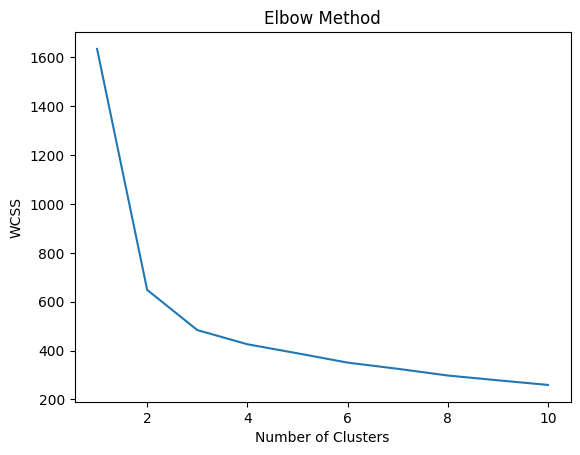

In [ ]:
wcss = [] # crear una lista para almacenar los valores de WCSS

# Calcular el WCSS para diferentes valores de k
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

# Gráfico del codo
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [ ]:
cluster_counts = data_cleaned['cluster'].value_counts()
cluster_counts

,count
cluster,
0,132
2,99
1,96


## Gráficos análisis

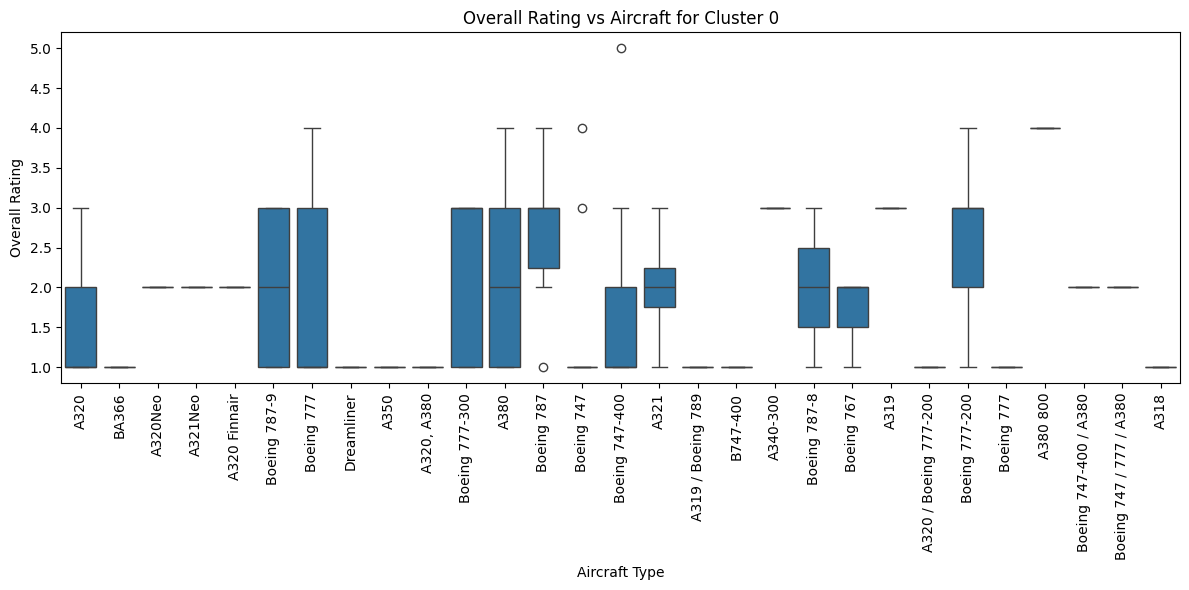

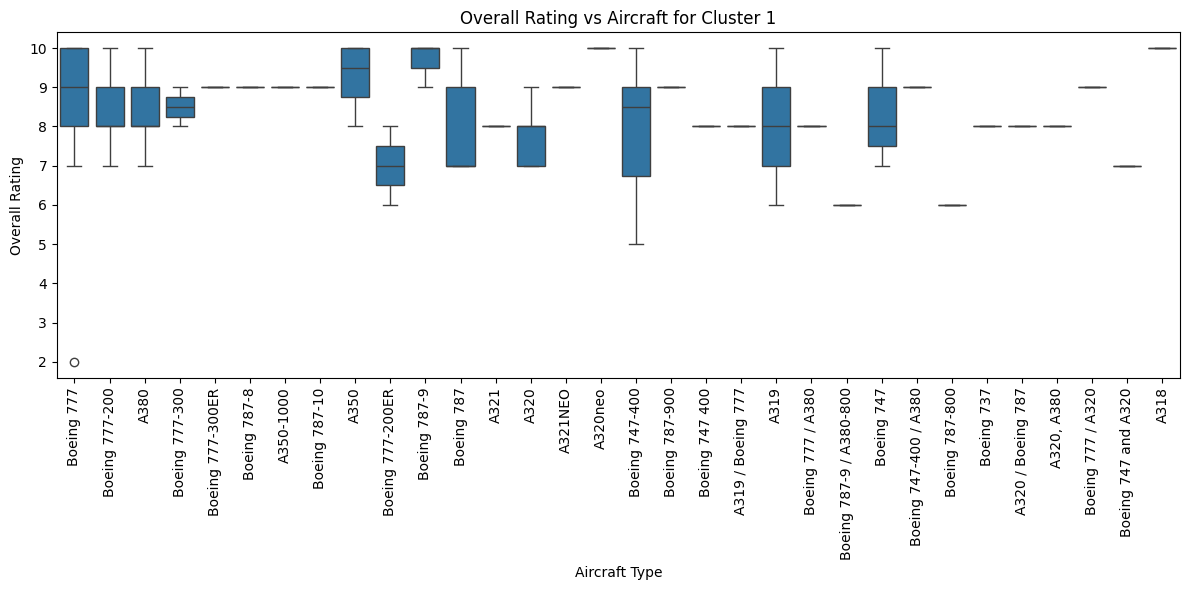

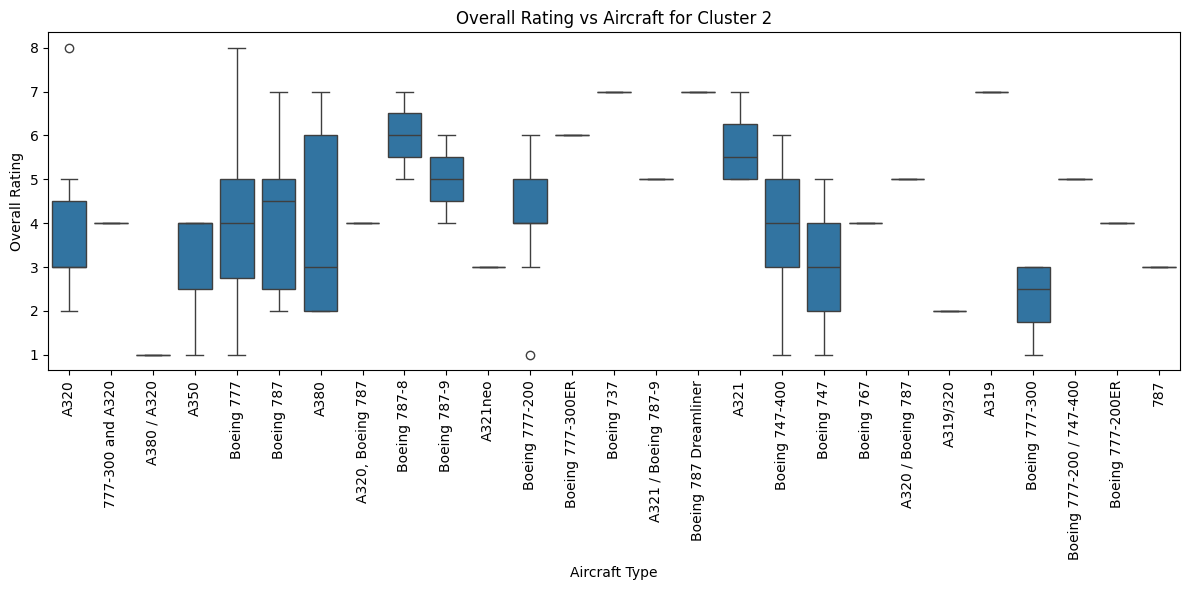

In [ ]:
# Crear boxplots por cada cluster
for cluster_id in data_cleaned['cluster'].unique():
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='Aircraft', y='OverallRating', data=data_cleaned[data_cleaned['cluster'] == cluster_id])
    plt.title(f'Overall Rating vs Aircraft for Cluster {cluster_id}')
    plt.xlabel('Aircraft Type')
    plt.ylabel('Overall Rating')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

### Aircraft vs Overall Rating
#### **Cluster 0**

**Calificación general baja:** Las calificaciones (Overall Rating) están concentradas entre 1 y 3.

**Baja variabilidad:** La mayoría de los tipos de aviones presentan mediana baja y poco rango.

**Outliers frecuentes:** Algunos aviones presentan valores atípicos (outliers) hacia arriba, lo que indica que aunque el cluster está caracterizado por calificaciones bajas, hay pasajeros que percibieron buen servicio en ciertos aviones.

**Conclusión:** Este cluster representa usuarios insatisfechos en general, independientemente del avión.

#### **Cluster 1**

**Calificación general alta:** La mayoría de las calificaciones están entre 7 y 10, con medianas muy elevadas.

**Variabilidad moderada:** Aunque algunos tipos de aviones presentan rangos amplios (e.g., Boeing 787), en general el servicio es bien percibido en este grupo.

**Conclusión:** Este cluster representa usuarios muy satisfechos con el servicio, sin importar el tipo de avión. Algunos aviones (como Boeing 777 y A350) parecen destacar.

#### **Cluster 2**

**Calificación intermedia:** Aquí las calificaciones varían ampliamente, con medianas alrededor de 4 a 6, y algunas cajas muy extendidas.

**Gran dispersión:** Se observa mayor dispersión y presencia de calificaciones extremas (de 1 a 7), lo que indica experiencias mixtas.

**Conclusión:** Este cluster representa usuarios con experiencias mixtas, con calificaciones promedio. Puede que ciertos aviones tengan mejor desempeño que otros.

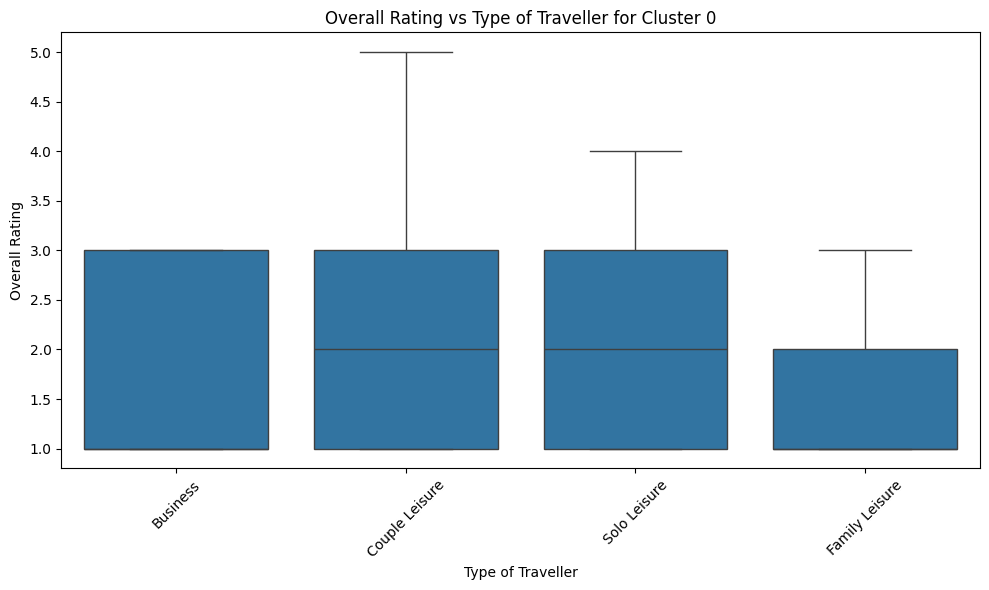

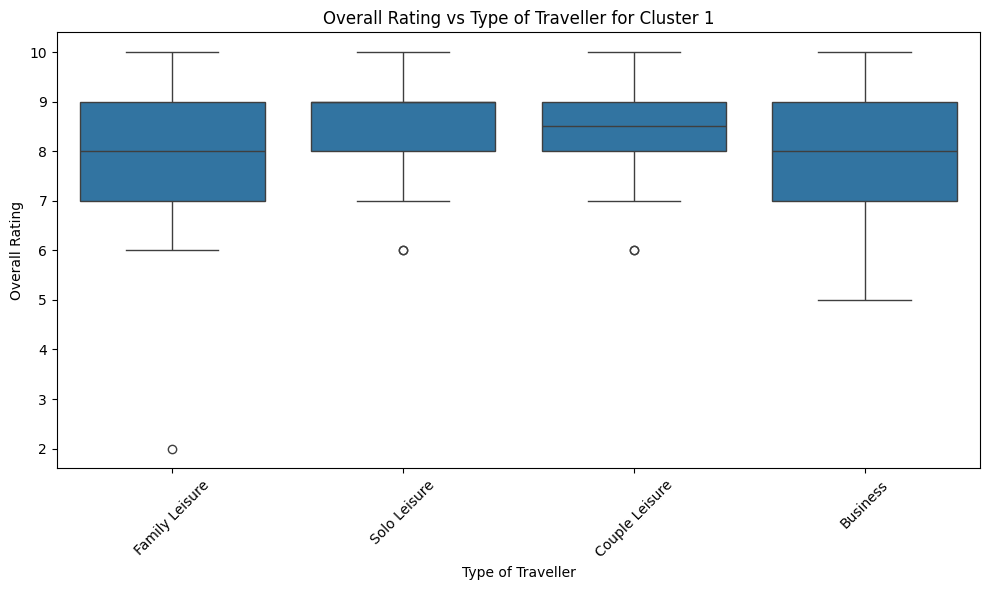

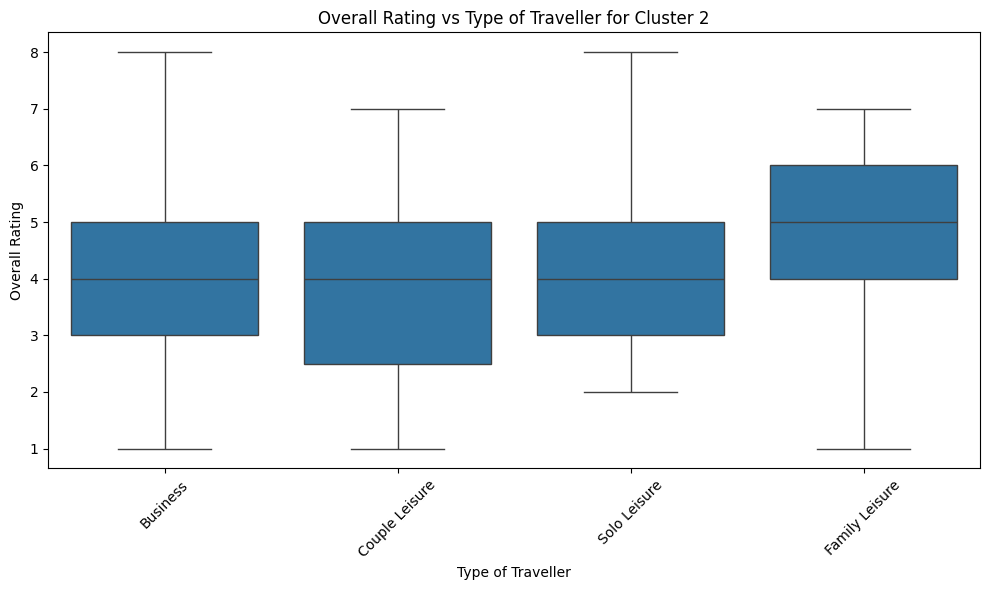

In [ ]:

# Gráfico para OverallRating vs TypeOfTraveller por cluster
for cluster_id in [0, 1, 2]:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='TypeOfTraveller', y='OverallRating', data=data_cleaned[data_cleaned['cluster'] == cluster_id])
    plt.title(f'Overall Rating vs Type of Traveller for Cluster {cluster_id}')
    plt.xlabel('Type of Traveller')
    plt.ylabel('Overall Rating')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Overall Rating vs Type Of Traveller
#### **Cluster 0**

Calificación general baja, concentrada en torno a 1-3 para todos los tipos de viajero (Business, Couple Leisure, Solo Leisure, Family Leisure).

Family Leisure tiene las calificaciones más bajas en promedio, indicando que los viajes familiares tienden a tener peor percepción en este cluster.

Business y Couple Leisure muestran calificaciones ligeramente más altas, pero dentro del rango bajo general.

**Conclusión:** Este cluster agrupa a usuarios insatisfechos, sin diferencias claras entre tipos de viajero, aunque los familiares tienden a estar más insatisfechos.

#### **Cluster 1**
Calificación general alta, con valores entre 7-10, especialmente para todos los tipos de viajero.

Family Leisure presenta algunas variaciones (outliers), pero sigue teniendo mediana alta.

Los viajeros Business y Couple Leisure muestran consistencia y satisfacción alta, con cajas estrechas y medianas altas (cercanas a 9).

**Conclusión:** Usuarios satisfechos en general, con buenos ratings independientemente del tipo de viaje.

#### **Cluster 2**
Calificación general intermedia, alrededor de 4-6, con variabilidad amplia.

No hay grandes diferencias entre tipos de viajero, aunque Family Leisure tiende a tener una mediana levemente superior al resto.

La variabilidad indica experiencias mixtas (buenas y malas) para todos los tipos de viajero.

**Conclusión:** Usuarios con experiencias promedio, y percepción algo mejor para los viajes familiares en comparación con otros grupos.



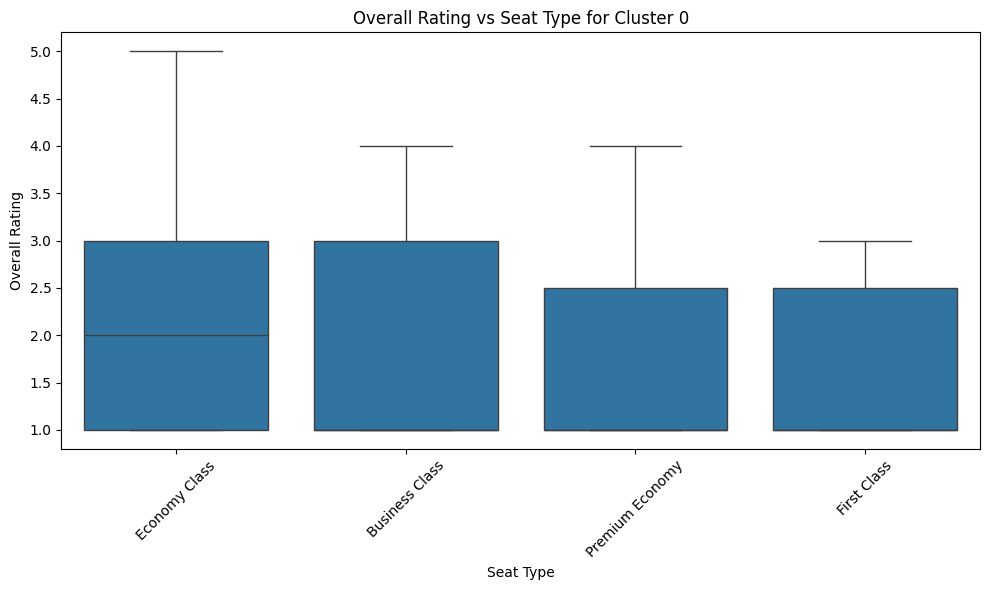

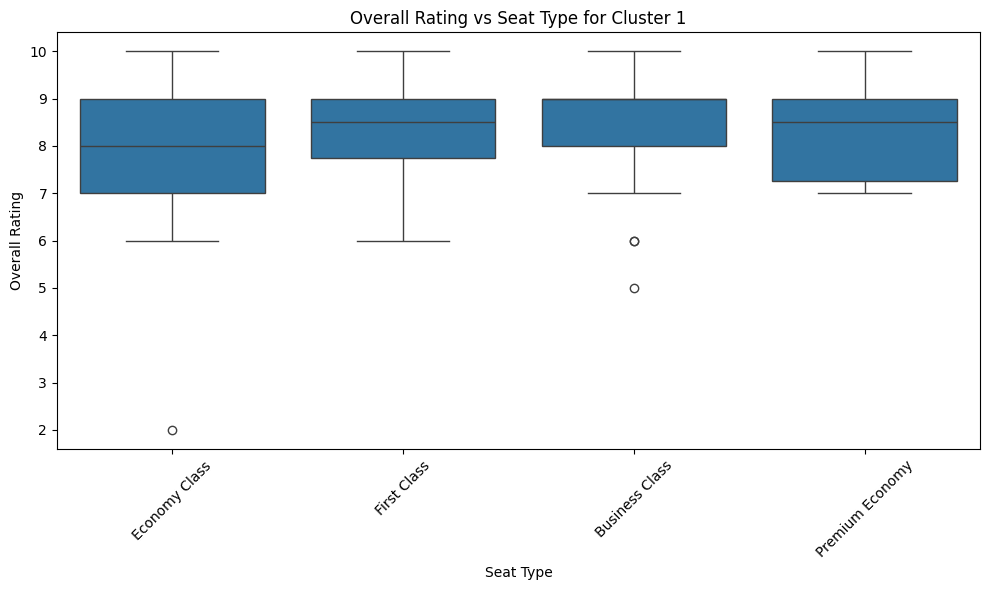

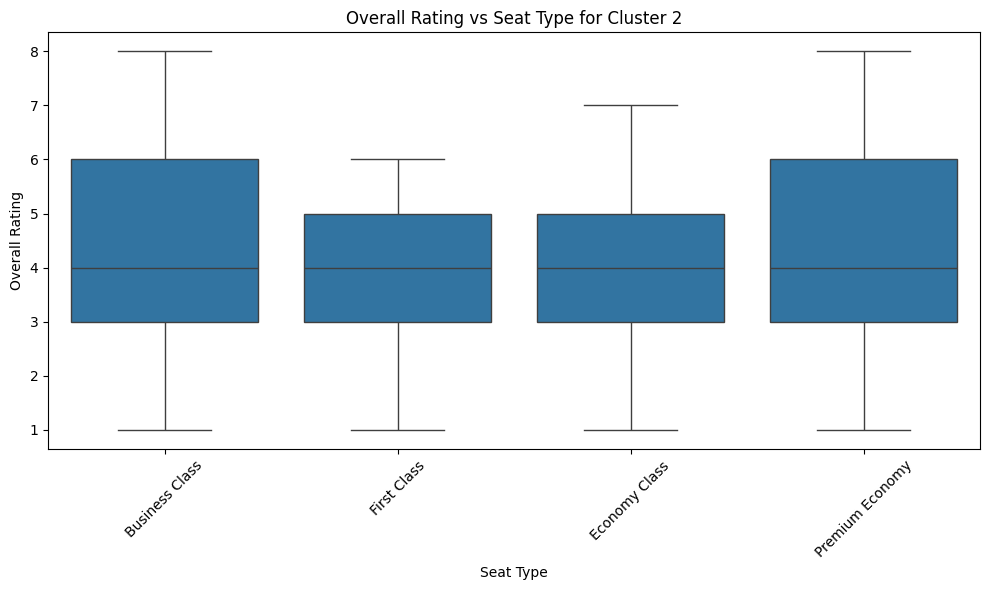

In [ ]:

# Gráfico para OverallRating vs SeatType por cluster
for cluster_id in [0, 1, 2]:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='SeatType', y='OverallRating', data=data_cleaned[data_cleaned['cluster'] == cluster_id])
    plt.title(f'Overall Rating vs Seat Type for Cluster {cluster_id}')
    plt.xlabel('Seat Type')
    plt.ylabel('Overall Rating')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### OverallRating vs SeatType
#### **Cluster 0**

**Calificaciones Generales:**

**Economy Class:** Promedio más bajo, alrededor de 2, indicando insatisfacción.

**Business Class:** Similar a Economy, con una ligera mejora.

**Premium Economy:** Promedio comparable, con no mucha variación.

**First Class:** Promedio también bajo, similar al resto, alrededor de 1.5.

**Observaciones:**

Todas las calificaciones son bastante bajas, sugiriendo problemas significativos en este clúster.

Las diferencias entre los tipos de asiento son menos pronunciadas, indicando insatisfacción general.

#### **Cluster 1**

**Calificaciones Generales:**

**Economy Class:** Promedio alrededor de 8, con buena consistencia.

**First Class:** Muy similar a Economy Class, alrededor de 9, sugiriendo alta satisfacción.

**Business Class:** Promedio ligeramente inferior, alrededor de 7, pero con menor variabilidad.

**Premium Economy:** Promedio comparable a Business Class.

**Observaciones:**

First Class muestra la calificación más alta, indicando una preferencia notable.
Todos los tipos de asientos presentan calificaciones elevadas, lo que sugiere buena percepción general.

#### **Cluster 2**

**Calificaciones Generales:**

**Business Class:** Calificación media cercana a 5, con una variabilidad moderada.

**First Class:** Calificación media alrededor de 4, con variabilidad similar pero con un rango más estrecho.

**Economy Class:** Media cerca de 4, con un rango más amplio, lo que sugiere opiniones más divididas.

**Premium Economy:** Media similar a Economy Class, con un pequeño rango.

**Observaciones:**

Business Class tiene la calificación más alta.

Hay una notable diferencia entre Business Class y First Class.

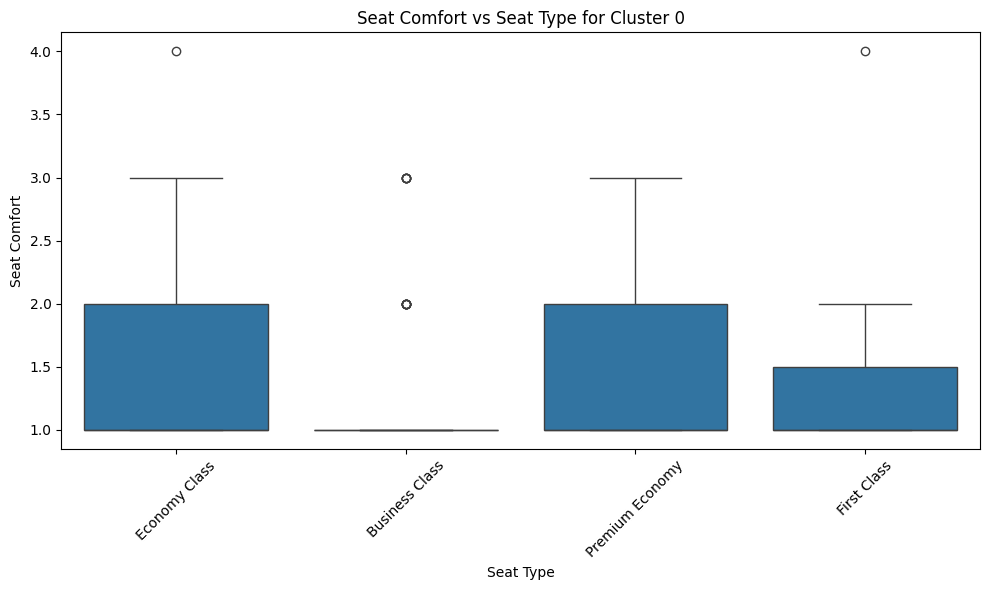

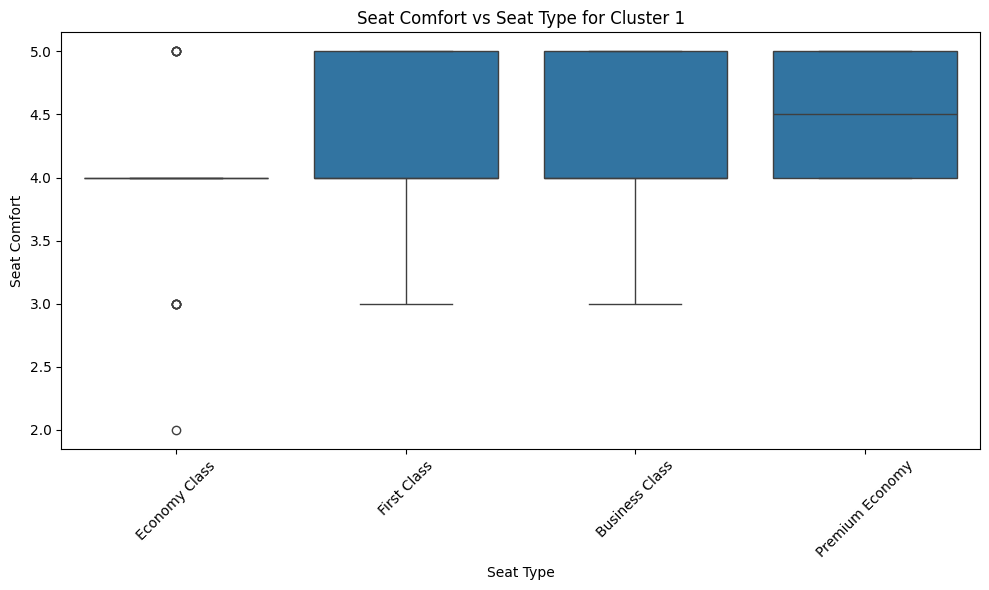

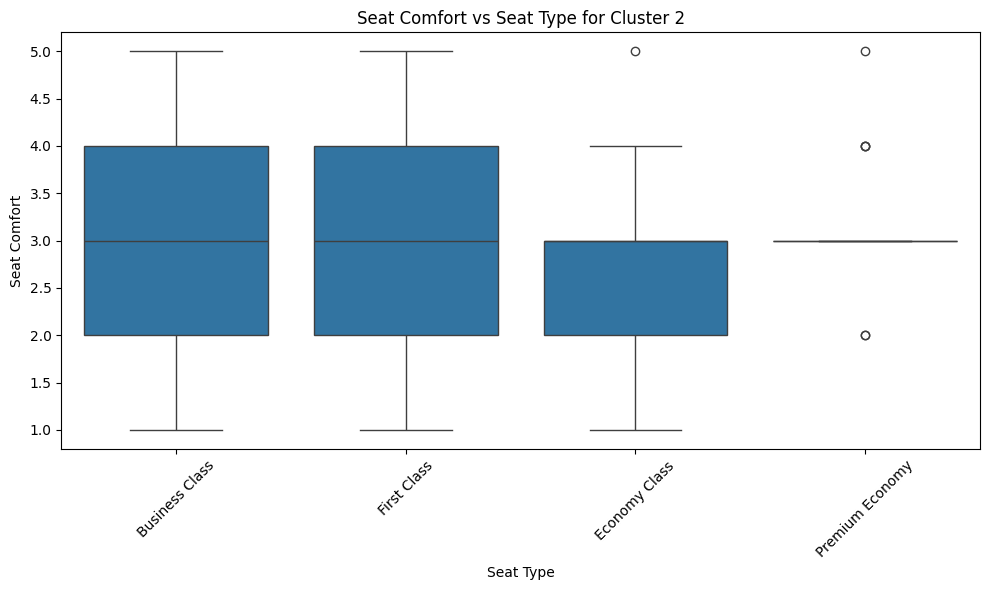

In [ ]:

# Gráfico para SeatComfort vs SeatType por cluster
for cluster_id in [0, 1, 2]:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='SeatType', y='SeatComfort', data=data_cleaned[data_cleaned['cluster'] == cluster_id])
    plt.title(f'Seat Comfort vs Seat Type for Cluster {cluster_id}')
    plt.xlabel('Seat Type')
    plt.ylabel('Seat Comfort')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Seat Comfort vs Seat Type
#### **Cluster 0**

First Class presenta el menor rango de confort, que apenas alcanza 2.0, lo que es inesperado.

Premium Economy tiene un rango moderado, sin embargo, no es suficiente para competir con las otras clases.

Economy Class presenta el rango más amplio, pero aún está por debajo de los estándares de confort de Business y Premium Economy.

Al igual que en otros clústeres, hay varios outliers, especialmente en Economy Class.

#### **Cluster 1**

First Class y Business Class son las que presentan mayor confort, con valores que alcanzan casi 5.0.

Premium Economy y Economy Class tienen rangos de confort significativamente más bajos, con Economy Class caracterizada por varios outliers que reflejan un confort notoriamente malo.

La dispersión para First y Business Class es nula, lo que indica consistencia en la percepción de confort entre los pasajeros.

#### **Cluster 2**

Business Class y First Class tienen niveles de confort similares, con un rango de aproximadamente 3.0 a 4.5.

Economy Class presenta un menor confort, con un rango que se sitúa entre 2.0 y 3.5.

Premium Economy muestra un rango de confort relativamente bajo en comparación con Business y First Class..

Outliers en Economy Class y Premium Economy indican algunos pasajeros que clasifican el confort notablemente bajo.

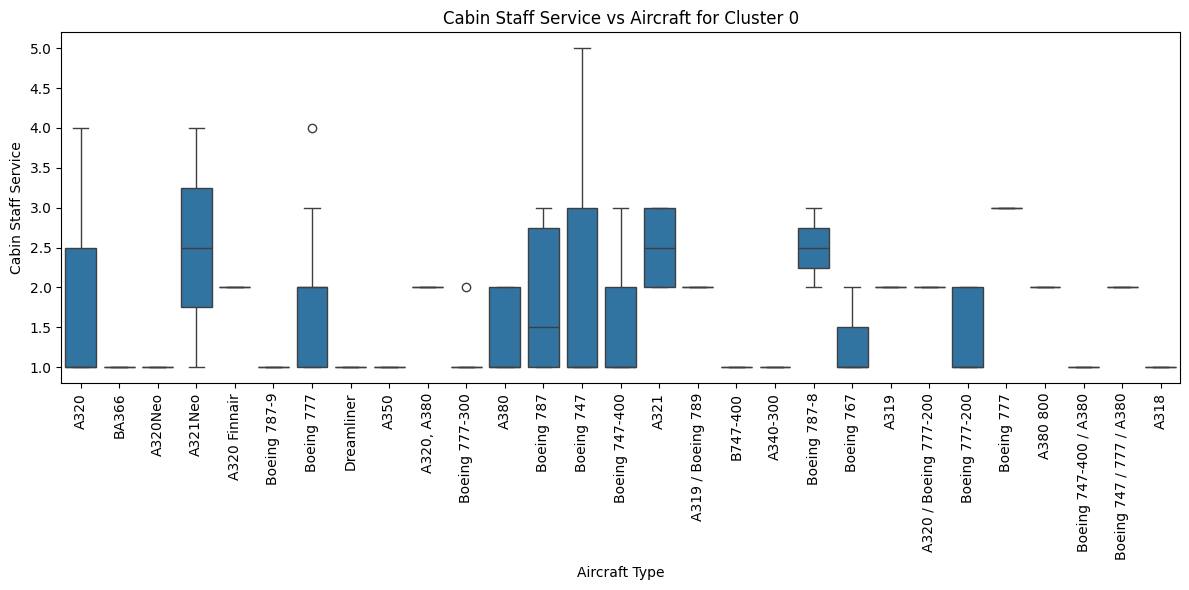

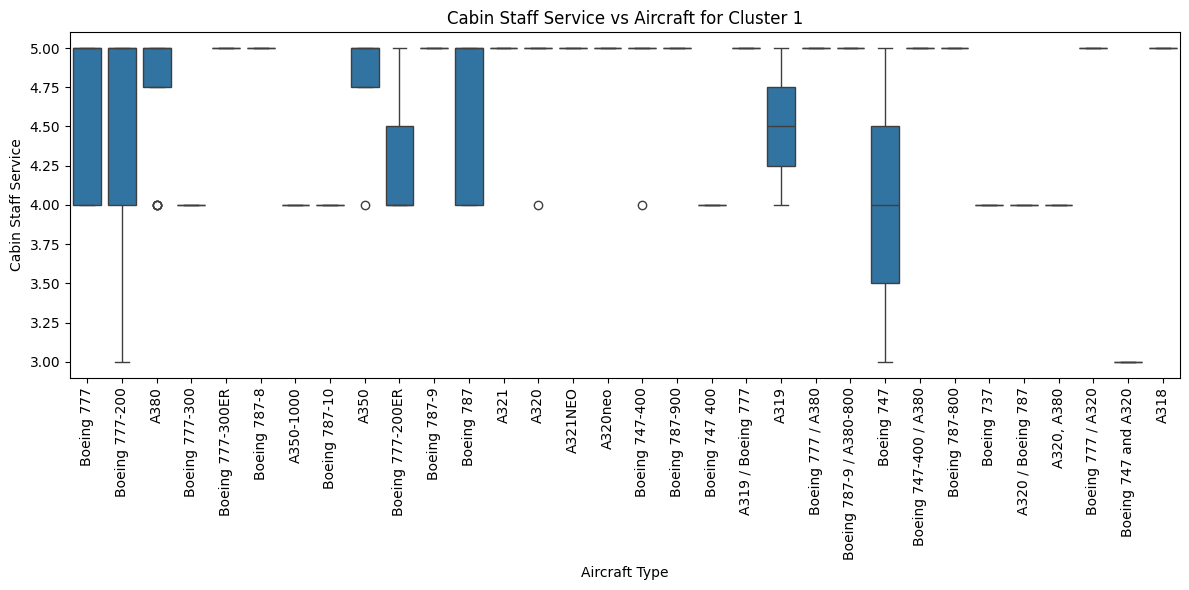

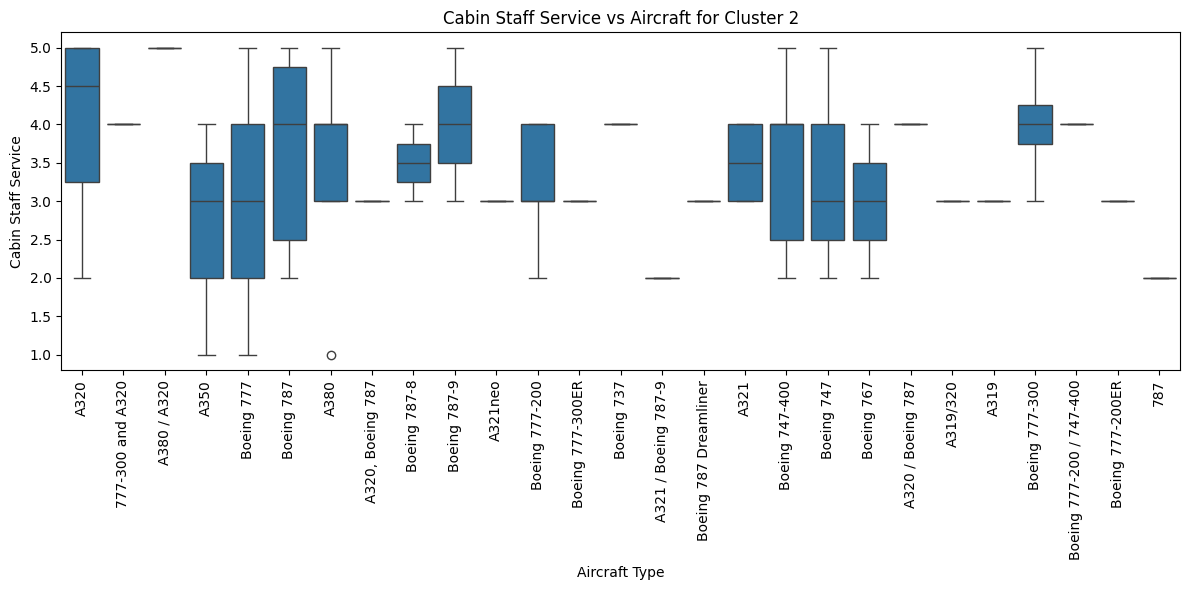

In [ ]:

# Gráfico para Aircraft vs CabinStaffService por cluster
for cluster_id in [0, 1, 2]:
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='Aircraft', y='CabinStaffService', data=data_cleaned[data_cleaned['cluster'] == cluster_id])
    plt.title(f'Cabin Staff Service vs Aircraft for Cluster {cluster_id}')
    plt.xlabel('Aircraft Type')
    plt.ylabel('Cabin Staff Service')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

### Aircraft vs Cabin Staff Service

#### **Cluster 0**

**Rango de Servicio:**
Este gráfico muestra un rango de servicio similar, desde aproximadamente 1.0 hasta 5.0.

**Aerónaves Destacadas:**

Las aeronaves Boeing 747 y A321 Neo tienen un rango de servicio más alto (cercano a 4.5).

Aeronaves como el A320 y Boeing 777-200 indican menor satisfacción en el servicio.

**Valores Atípicos:**
Se identifican valores atípicos en aeronaves que enfrentan variaciones significativas en el servicio, sugiriendo diferencias notables en la experiencia del personal de cabina ofrecida.

#### **Cluster 1**

**Rango de Servicio:**
El rango de servicio se mantiene entre aproximadamente 3.0 y 5.0.

**Aerónaves Destacadas:**

El Boeing 777 y el A380 alcanzan buenos niveles de servicio superior a 4.5.

Aeronaves como el A319, Boeing 747 y 777-200 presentan una varianza considerable.

**Valores Atípicos:**
Hay varios puntos atípicos en este clúster, especialmente entre el Boeing 747-400 y el A320, lo que sugiere inconsistencias en la calidad del servicio.

#### **Cluster 2**

**Rango de Servicio:**
Los valores de servicio del personal de cabina varían entre aproximadamente 1.5 y 5.

**Aerónaves Destacadas:**

A320 y Boeing 787 muestran una tendencia a puntuaciones de servicio más altas.

Algunas aeronaves, como el Boeing 777 y A380, también tienen razonables puntuaciones.

**Valores Atípicos:**
Se observan puntos atípicos (outliers) en el A380, indicando posiblemente servicios que han sido excepcionalmente malos.

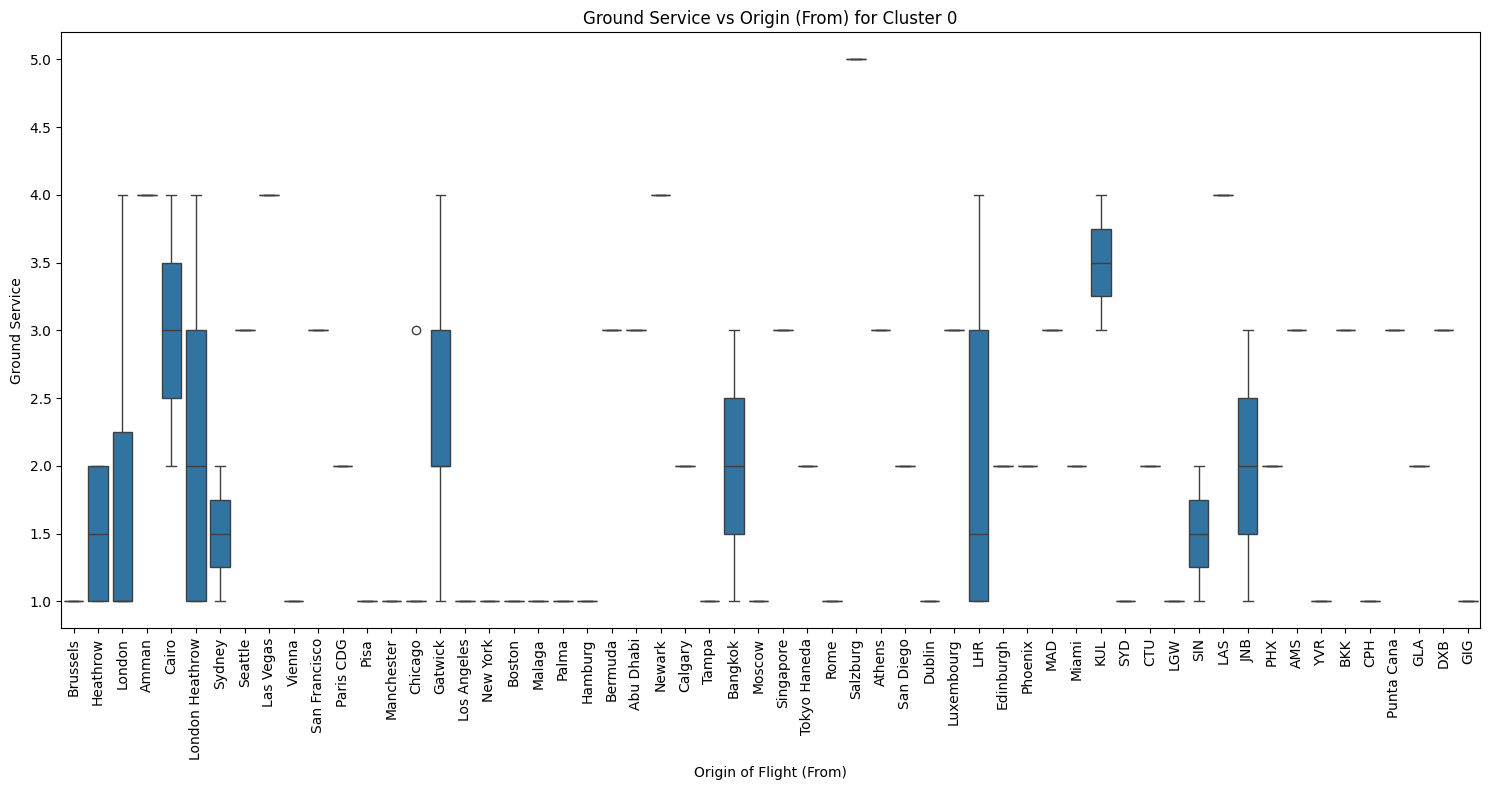

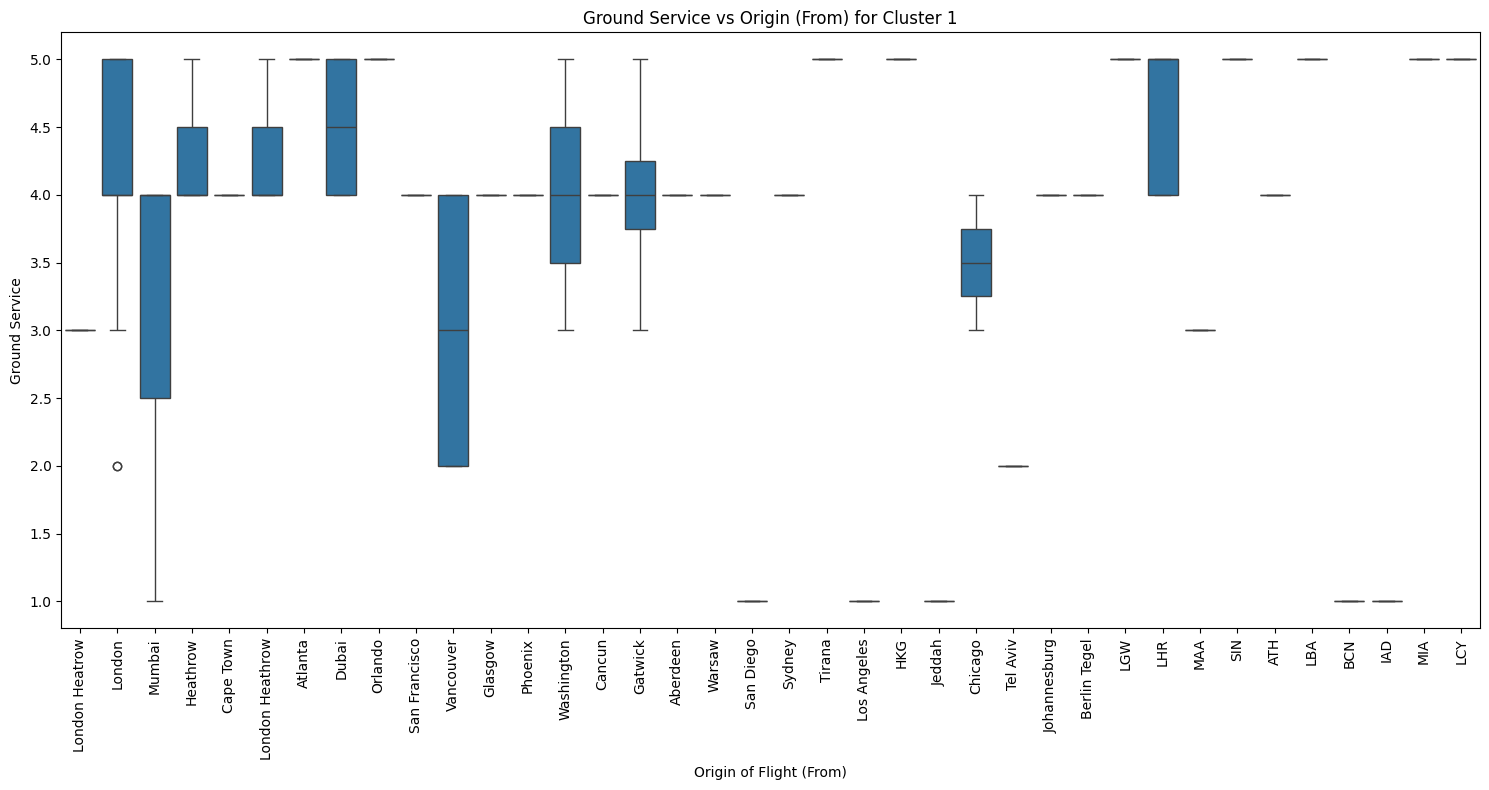

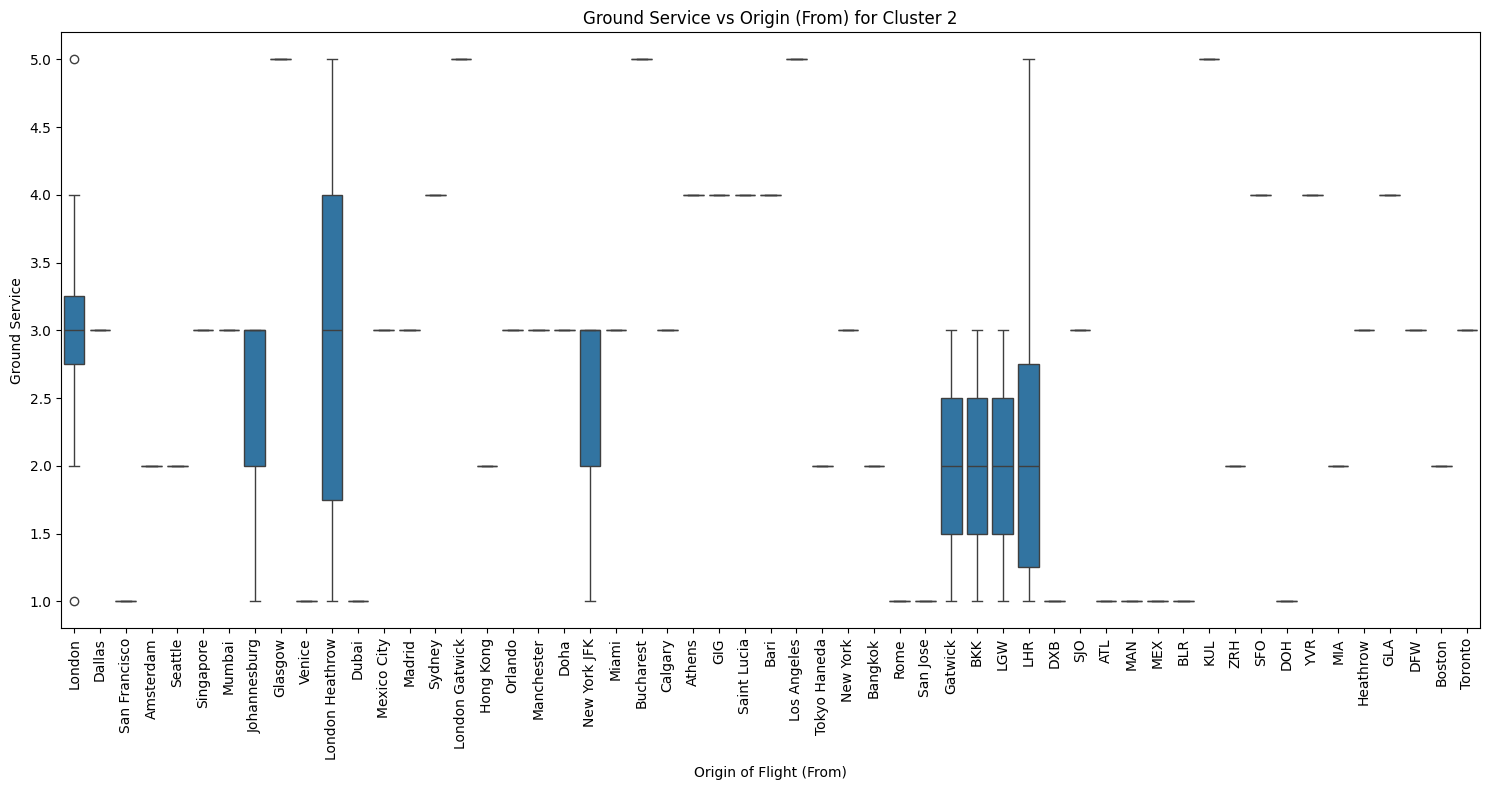

In [ ]:

# Gráfico para GroundService vs From por cluster
for cluster_id in [0, 1, 2]:
    plt.figure(figsize=(15, 8))
    sns.boxplot(x='From', y='GroundService', data=data_cleaned[data_cleaned['cluster'] == cluster_id])
    plt.title(f'Ground Service vs Origin (From) for Cluster {cluster_id}')
    plt.xlabel('Origin of Flight (From)')
    plt.ylabel('Ground Service')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

### Ground Service vs From

#### Cluster 0

**Hallazgos Clave:**

**Puntos Altos en Servicio:**
Las puntuaciones más altas provienen de lugares como Luxemburgo y Edimburgo, que tienen calificaciones alrededor de 4.0.

**Puntos Críticos:**
Varias ciudades como París y Barcelona muestran calificaciones muy bajas, cercanas a 2.0.

**Dispersión y Tendencias:**
La gráfica indica una considerable variabilidad en los resultados, lo que refleja diferencias en la calidad del servicio en tierra entre los diferentes orígenes.

#### Cluster 1

**Hallazgos Clave:**

**Lugares Destacados:**
Londres Heathrow y New York JFK tienen puntuaciones de servicio más altas, en torno a 4.0.

**Lugares con Puntuaciones Bajas:**
Mumbai y Orlando muestran calificaciones significativamente más bajas, con puntuaciones que rondan 2.0.

**Tendencias:**
Se observa un rango variado en la puntuación del servicio en tierra, lo que sugiere inconsistencia en la calidad.

#### Cluster 2

**Hallazgos Clave:**

**Lugares con Mejor Servicio:**
Londres y Dubai presentan calificaciones de servicio en tierra más altas, con valores cercanos a 4.0.

**Lugares con Peor Servicio:**
Las ciudades como Nueva York y Los Ángeles tienen calificaciones más bajas, alrededor de 2.0.

**Dispersión:**
Hay una notable dispersión en las puntuaciones, lo que indica variaciones significativas en la calidad del servicio de tierra para diferentes orígenes.

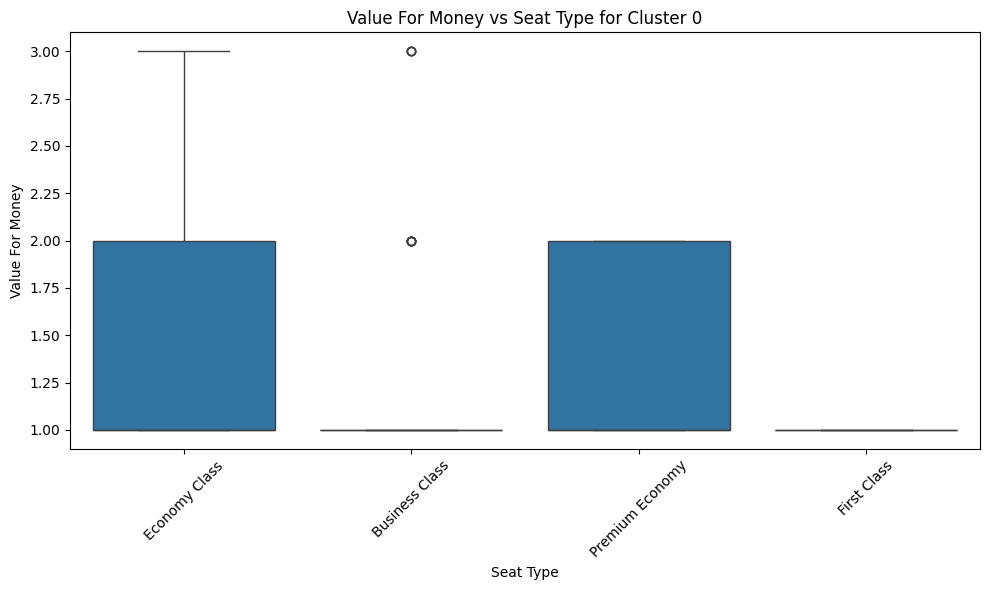

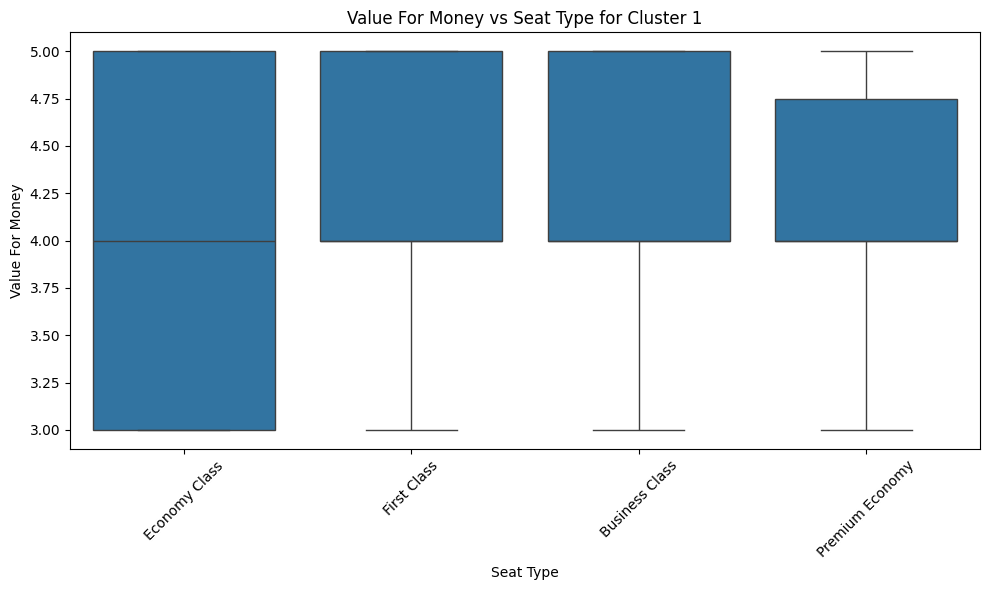

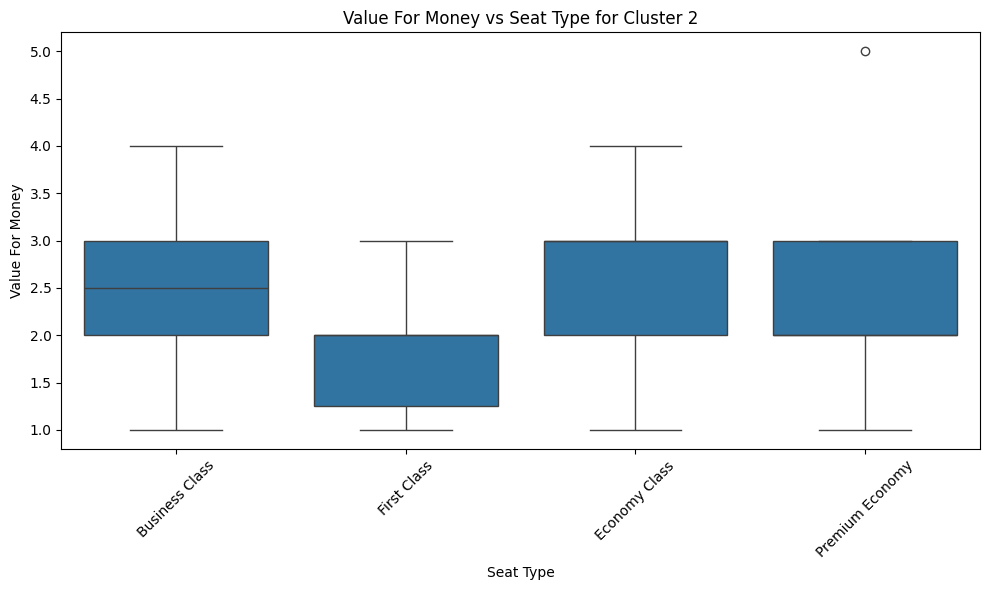

In [ ]:

# Gráfico para ValueForMoney vs SeatType por cluster
for cluster_id in [0, 1, 2]:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='SeatType', y='ValueForMoney', data=data_cleaned[data_cleaned['cluster'] == cluster_id])
    plt.title(f'Value For Money vs Seat Type for Cluster {cluster_id}')
    plt.xlabel('Seat Type')
    plt.ylabel('Value For Money')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


### Seat Type vs Value For Money
#### **Cluster 0**
**Tipo de Asiento:**

Economy Class: Mediana alrededor de 2.0.,

Business Class: Casi no presenta valor (muy cerca de 1.0).

Premium Economy: Cerca de 1.5, también bajo.

First Class: Casi no presenta valor (muy cerca de 1.0).

**Observaciones:**

Economy Class, aunque es la mejor entre las tres en este grupo, sigue siendo baja.

Business y Premium Economy no ofrecen un buen valor por el dinero.
#### **Cluster 1**
**Tipo de Asiento:**

Economy Class: Mediana baja alrededor de 3.0.

First Class: Mediana alta, cerca de 4.75.

Business Class: Mediana moderada, cercana a 4.0.

Premium Economy: Similar a Business, pero con una ligera ventaja.

**Observaciones:**

First Class muestra el mejor valor por dinero.

Economy Class es significativamente más baja en comparación con las otras clases.
#### **Cluster 2**
**Tipo de Asiento:**

Business Class: Mediana alrededor de 3.0.

First Class: Mediana más baja, cerca de 2.5.

Economy Class: Mediana similar a First, también alrededor de 2.5.

Premium Economy: Mediana más alta, cerca de 3.5.

**Observaciones:**

La clase Ejecutiva tiene un rango más amplio, pero no necesariamente el mejor
valor.

Economy y First Class tienen un valor más bajo en comparación con el Premium Economy.

**Conclusiones Generales**

**Tendencias:**

Economy Class tiende a tener un valor bajo en todos los clústeres.

First Class está bien valorada en el Cluster 1, pero no en los otros.

Premium Economy parece ser una opción intermedia en Cluster 2, pero no entrega buen valor en Cluster 0.

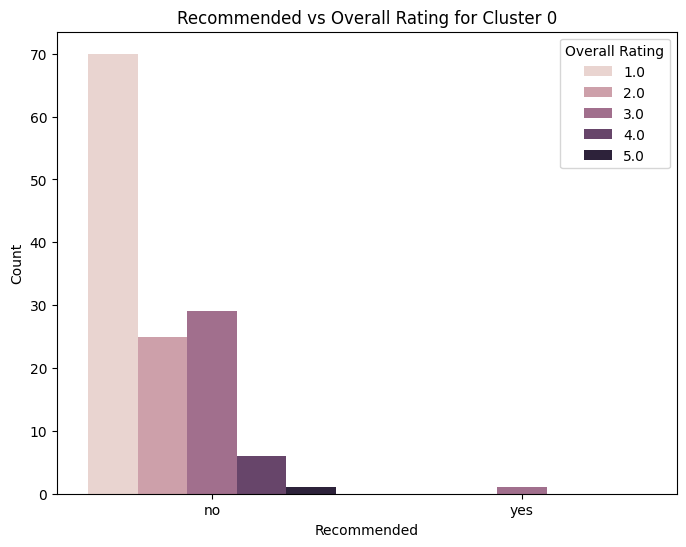

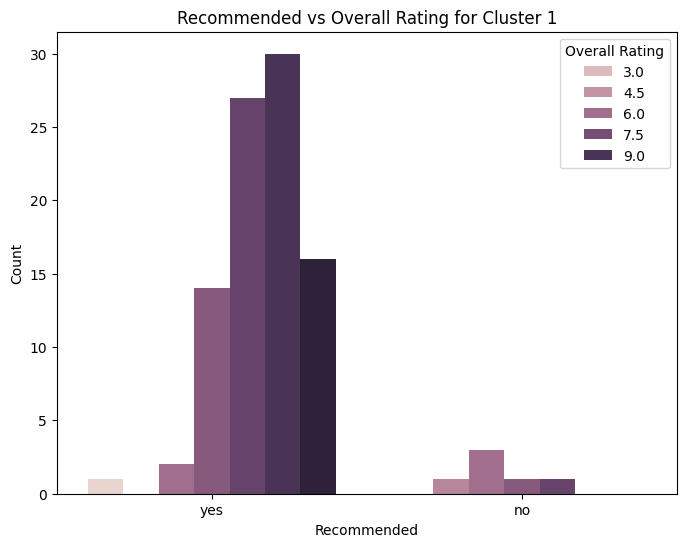

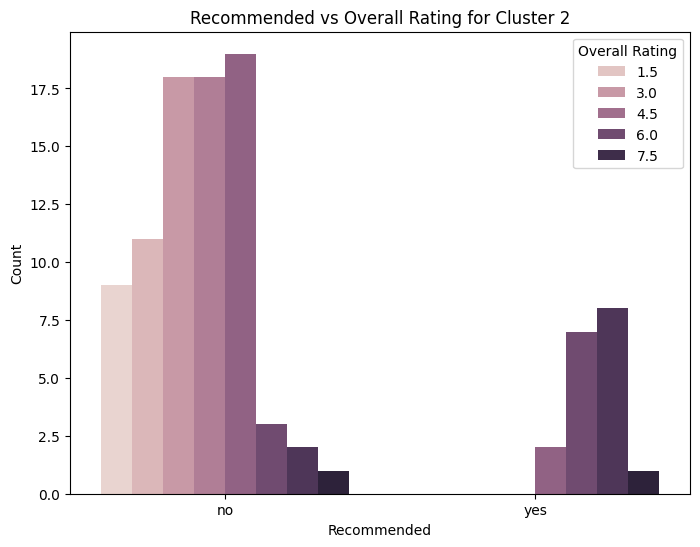

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

# Gráfico para Recommended vs Overall Rating por cluster
for cluster_id in [0, 1, 2]:
    plt.figure(figsize=(8, 6))
    sns.countplot(x='Recommended', hue='OverallRating', data=data_cleaned[data_cleaned['cluster'] == cluster_id])
    plt.title(f'Recommended vs Overall Rating for Cluster {cluster_id}')
    plt.xlabel('Recommended')
    plt.ylabel('Count')
    plt.legend(title='Overall Rating')
    plt.show()

### Recommended vs Overall Rating
#### **Cluster 0**
**Distribución de Recomendaciones:**
Predomina la categoría "no" (70 recuentos) comparado con "sí".

**Calificación General:**
La calificación general más frecuente es de 1.0, con un número considerable de conteos en calificaciones de 2.0.
Muy pocas calificaciones alcanzan 4.0 o 5.0.

**Interpretación:**
La mayoría de los usuarios no recomienda el producto con calificaciones bajas.
#### **Cluster 1**
**Distribución de Recomendaciones:**
La mayoría de las respuestas están en "sí" (30+ recuentos) en comparación con "no".

**Calificación General:**
Las calificaciones más comunes oscilan entre 3.0 y 6.0, existiendo menos conteos en 7.5 y 9.0.

**Interpretación:**
Los usuarios que recomendaron el producto generalmente le dieron calificaciones moderadamente altas.
#### **Cluster 2**
**Distribución de Recomendaciones:**

Similar a Cluster 0, los recuentos de "no" son mayores que los de "sí".

**Calificación General:**
La calificación más común es 4.5, seguido de 1.5 y 3.0.

El recuento en la categoría de "sí" es bajo en comparación con las calificaciones.

**Interpretación:**
A pesar de algunos usuarios que no lo recomendaron, aquellos que lo hicieron generalmente tienen una calificación más alta en comparación con Cluster 0.


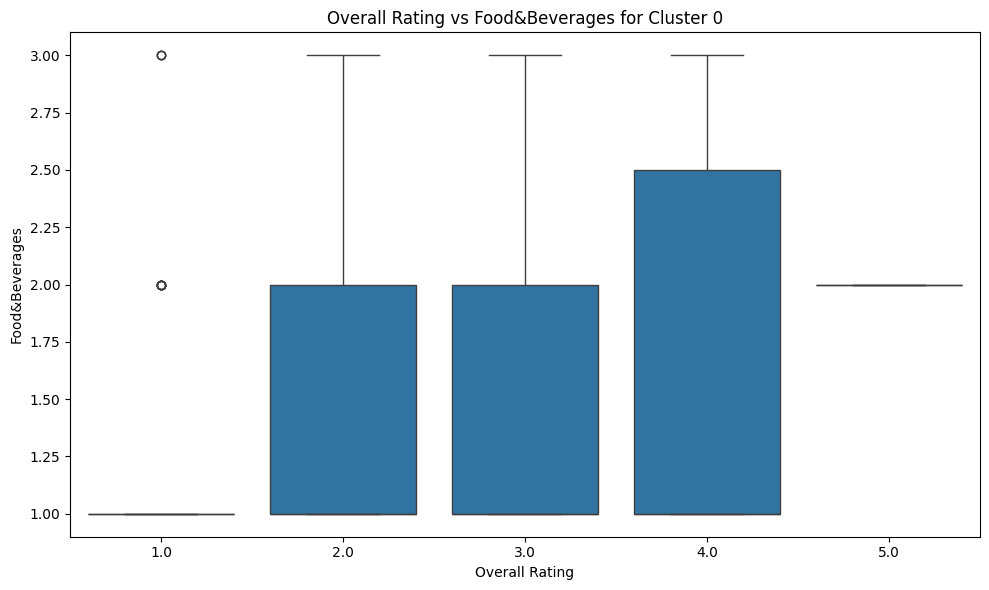

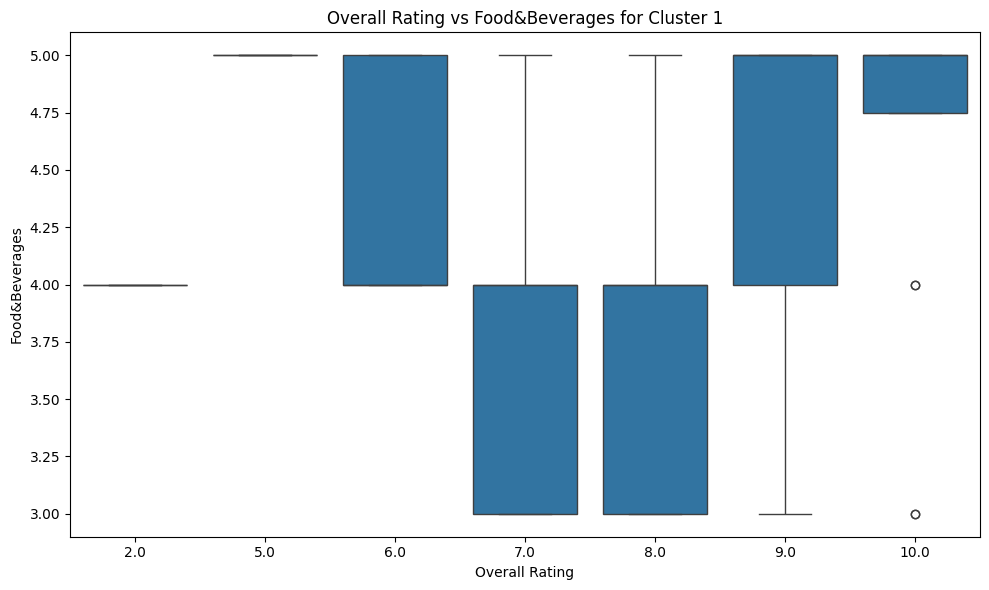

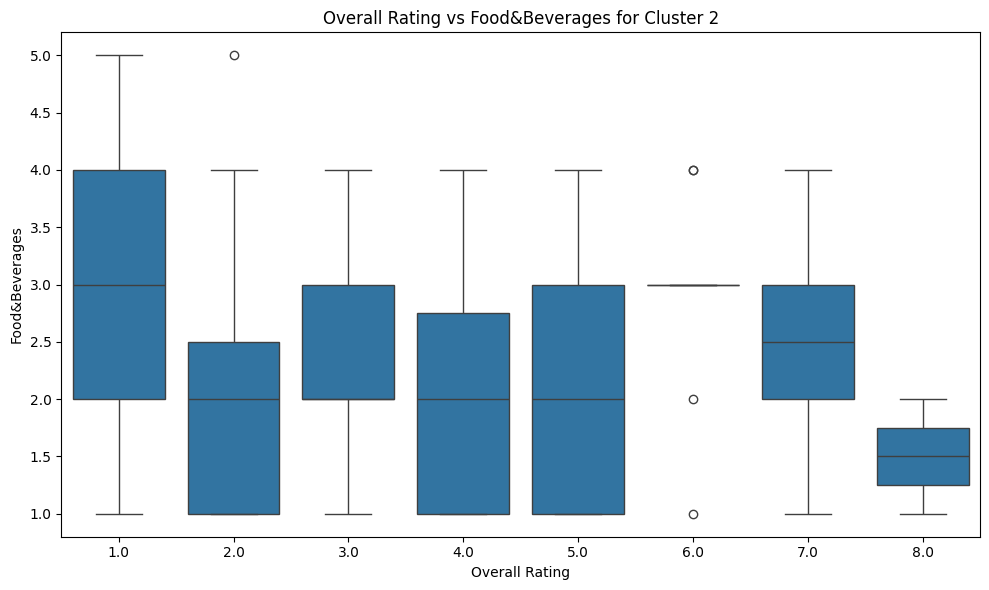

In [ ]:

# Gráfico para OverallRating vs Food&Beverages por cluster
for cluster_id in [0, 1, 2]:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='OverallRating', y='Food&Beverages', data=data_cleaned[data_cleaned['cluster'] == cluster_id])
    plt.title(f'Overall Rating vs Food&Beverages for Cluster {cluster_id}')
    plt.xlabel('Overall Rating')
    plt.ylabel('Food&Beverages')
    plt.tight_layout()
    plt.show()

### Overall Rating vs Food & Beverages
#### **Clúster 0**
**Rango de Ratings:**
Los ratings van desde 1 a 5.

**Distribución:**

La mayoría de las calificaciones de alimentos y bebidas son en torno a 2.0 a 2.5, con menos variación en comparación con los otros clústeres.

Se presentan algunos outliers en el extremo inferior.

**Tendencias:**
La relación entre el rating general y la calificación de alimentos y bebidas es más homogénea, sin grandes picos.
#### **Clúster 1**
**Rango de Ratings:**
Este clúster muestra ratings desde 2 hasta 10.

**Distribución:**

Hay una concentración significativa de ratings alrededor de 7 a 8, con la mayoría de las calificaciones de alimentos y bebidas en el rango de 4.0 a 5.0.

Se observan varios valores atípicos en el extremo superior (cerca de 10).

**Tendencias:**
La calificación de alimentos y bebidas es generalmente alta, pero la variabilidad es notable.
#### **Clúster 2**
**Rango de Ratings:**
El rango de ratings oscila entre 1 y 8.

**Distribución:**

La mediana parece ser de alrededor de 2.5 a 4.0 para la mayoría de los ratings generales.

Se observan algunos valores atípicos en la parte baja (0 o 1) y en la parte alta (6 a 8).

**Tendencias:**
La calificación de alimentos y bebidas parece aumentar ligeramente conforme el rating general se incrementa.

**Conclusiones Generales:**

Existen diferencias notables entre los clústeres en términos de calificación de alimentos y bebidas según el rating general.

Clúster 1 parece tener la calificación de alimentos y bebidas más alta y menos dispersa, mientras que Clúster 2 presenta una relación más variable con algunos valores atípicos.

Clúster 0 muestra una relación más débil entre el rating general y la calificación de alimentos y bebidas.

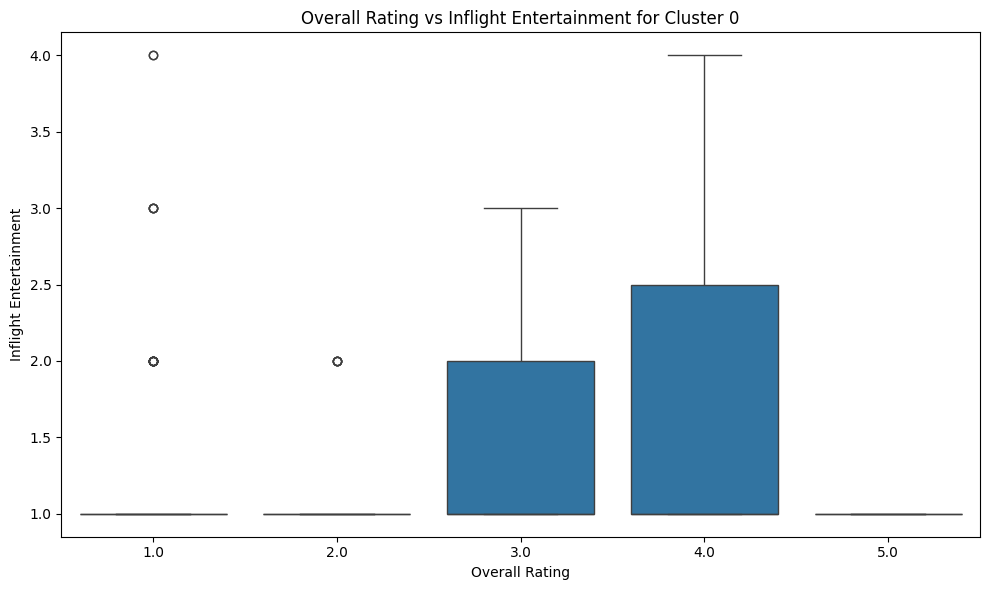

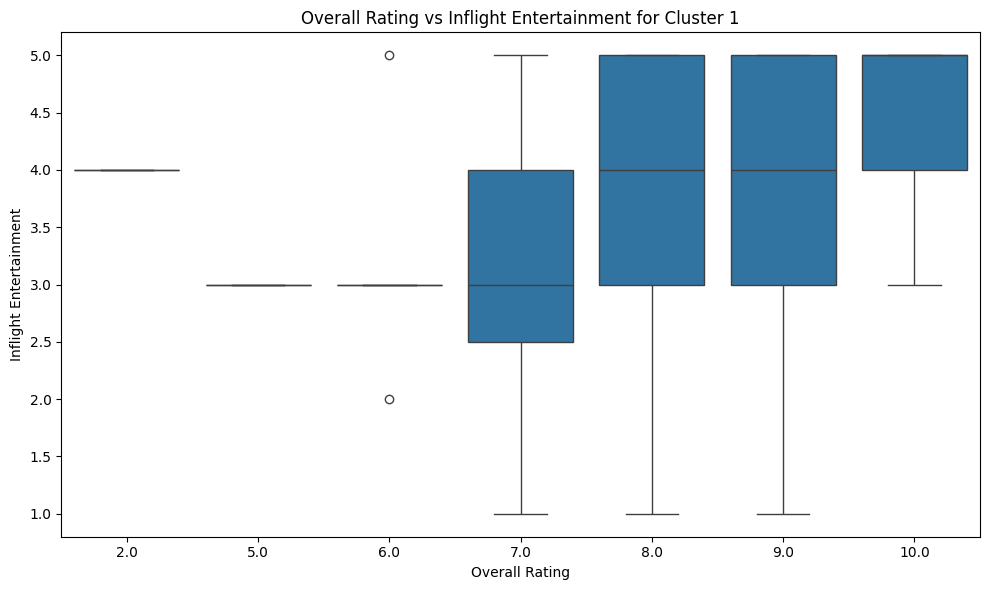

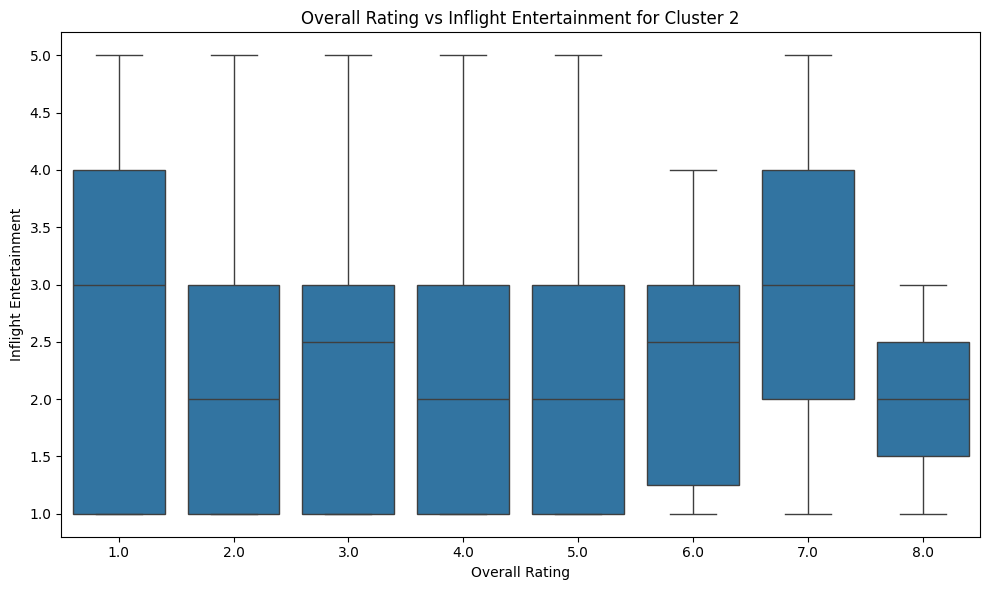

In [ ]:

# Gráfico para OverallRating vs InflightEntertainment por cluster
for cluster_id in [0, 1, 2]:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='OverallRating', y='InflightEntertainment', data=data_cleaned[data_cleaned['cluster'] == cluster_id])
    plt.title(f'Overall Rating vs Inflight Entertainment for Cluster {cluster_id}')
    plt.xlabel('Overall Rating')
    plt.ylabel('Inflight Entertainment')
    plt.tight_layout()
    plt.show()

### Overall Rating vs Inflight Entertainment
#### **Cluster 0**
**Rango de Calificaciones:** 1.0 a 5.0.

**Observaciones:**

La mediana de entretenimiento a bordo es más baja que en los otros dos clusters, indicando que las calificaciones generales también son más bajas.

Se observan valores atípicos que refuerzan la baja calidad del entretenimiento, sugiriendo que las mejoras podrían fomentar mayores calificaciones generales.
#### **Cluster 1**
**Rango de Calificaciones:** 2.0 a 10.0.

**Observaciones:**

La mediana de la calificación de entretenimiento para las calificaciones más altas (7.0 a 10.0) se mantiene cerca de 4.0.

Se observa poco rango intercuartílico en las calificaciones más altas, insinuando una consistencia en la calidad del entretenimiento.

Hay valores atípicos en la calificación más baja, que corresponden a un entretenimiento a bordo inferior.
#### **Cluster 2**
**Rango de Calificaciones:** 1.0 a 8.0.

**Observaciones:**

Hay una tendencia a que un mayor puntaje en calificación general se asocie con un entretenimiento a bordo mejor calificado.

La mediana de entretenimiento es mayor para calificaciones entre 1.0 y 3.0, pero tiende a bajar a medida que se acerca a 8.0.

La variabilidad del entretenimiento a bordo es evidente, con algunos valores extremos superiores a 4.5.

**Conclusiones Generales**

**Relación clara:** Hay una relación evidente entre la calificación general y el entretenimiento a bordo a través de los clusters.

**Variabilidad en las Experiencias:** Los niveles de entretenimiento a bordo varían considerablemente, lo cual podría influir en la satisfacción general del vuelo.

**Oportunidades de Mejora:** Los clusters con puntajes más bajos podrían beneficiarse de mejoras en la calidad del entretenimiento a bordo para aumentar la satisfacción del cliente.

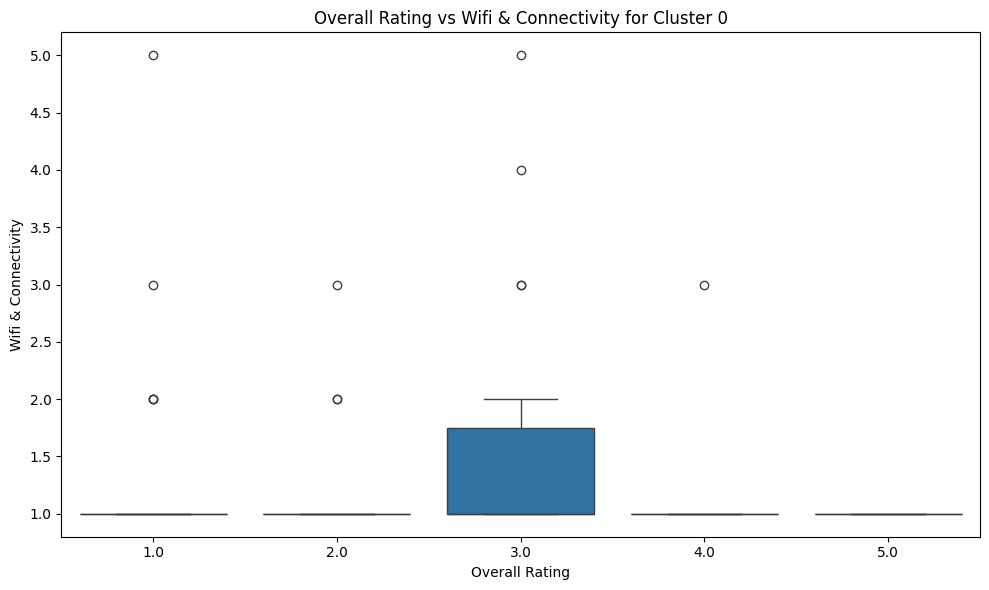

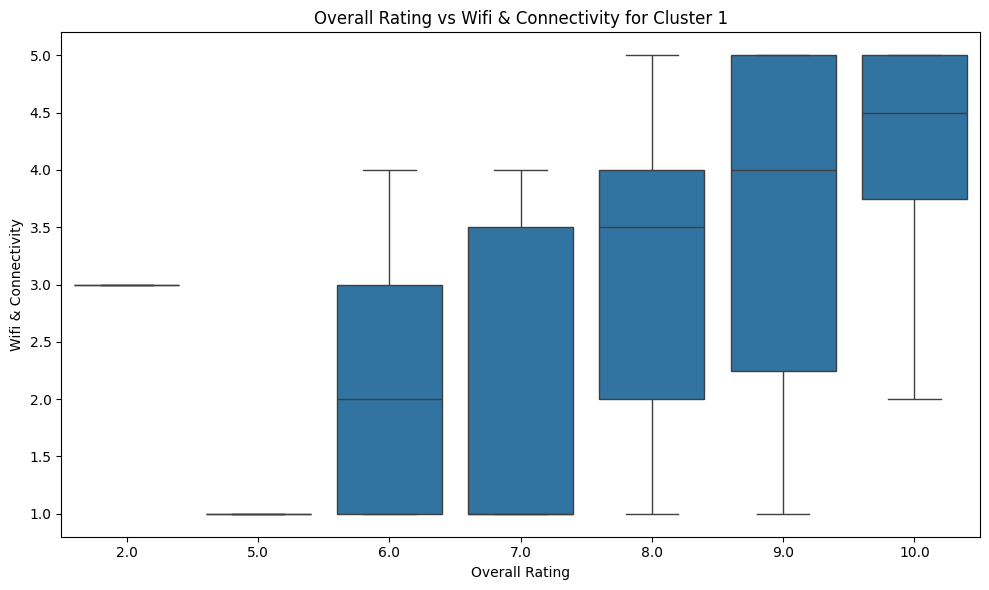

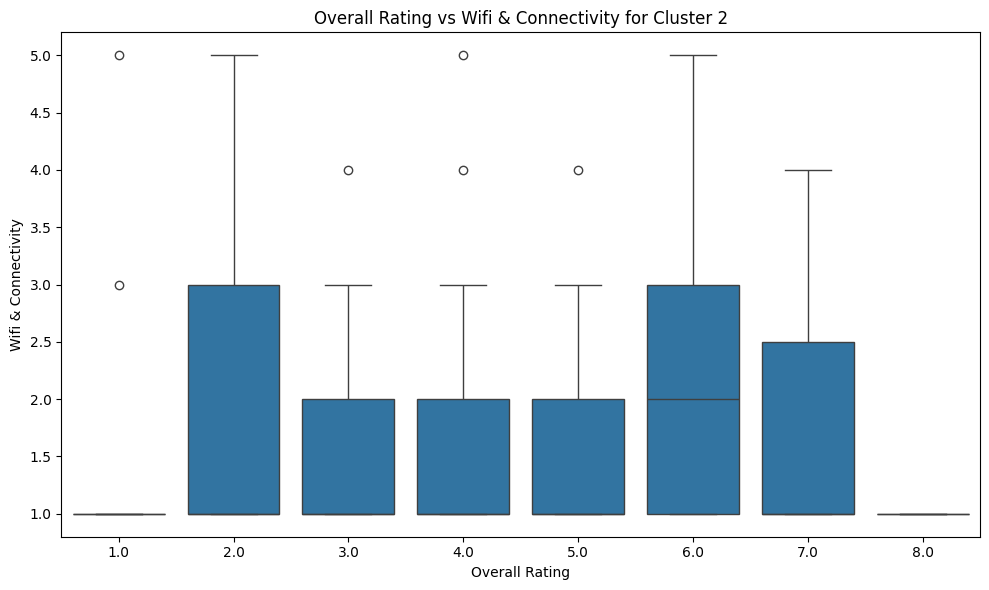

In [ ]:

# Gráfico para OverallRating vs Wifi&Connectivity por cluster
for cluster_id in [0, 1, 2]:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='OverallRating', y='Wifi&Connectivity', data=data_cleaned[data_cleaned['cluster'] == cluster_id])
    plt.title(f'Overall Rating vs Wifi & Connectivity for Cluster {cluster_id}')
    plt.xlabel('Overall Rating')
    plt.ylabel('Wifi & Connectivity')
    plt.tight_layout()
    plt.show()

### Overall Rating vs Wifi & Connectivity

#### **Cluster 0**

**Rango de calificaciones:** Las calificaciones están restringidas entre 1 y 5.

**Mediana:** La mediana es cercana a 1.5, lo que indica una evaluación muy baja de WiFi y conectividad.

**Dispersión:** Muestra poca variabilidad, con un intercuartil que sugiere que las calificaciones son consistentemente bajas.

**Outliers:** Hay varios outliers, pero la mediana y los cuartiles son considerablemente bajos.
#### **Cluster 1**

**Rango de calificaciones:** Este cluster tiene calificaciones que van del 2 al 10.

**Mediana:** La mediana es notablemente más alta, alrededor de 7.5. Este grupo parece tener una percepción más positiva sobre WiFi y conectividad.

**Dispersión:** Hay una menor variabilidad comparado con el Cluster 2, lo que sugiere una mayor uniformidad en la opinión sobre la calidad de WiFi.

**Outliers:** Se presentan algunos outliers, pero menos que en el Cluster 2.
#### **Cluster 2**

**Rango de calificaciones:** Las calificaciones generales varían de 1 a 8.

**Mediana:** La mediana de WiFi y conectividad se sitúa cerca de 2.5, mostrando una puntuación baja en este aspecto.

**Dispersión:** Presenta una amplia dispersión con un rango intercuartílico que indica variabilidad en las opiniones.

**Outliers:** Se observan varios puntos atípicos (outliers), especialmente en las calificaciones más altas.

**Conclusiones Generales**

**Tendencia de la Calidad:** Hay un claro contraste entre los clusters en términos de la calidad percibida de WiFi y conectividad.

Cluster 1 es el más positivo, mientras que el Cluster 0 es el más negativo en cuanto a las calificaciones.

**Variabilidad:** La variabilidad en las opiniones es alta en Clusters 2 y 1, mientras que en el Cluster 0 es más uniforme, es decir, la mayoría de los usuarios comparten una opinión negativa.

## Modelo guardado

In [ ]:
import joblib # Esta librería sirve para guardar y llamar objetos de Python, como los modelos de machine learning
joblib.dump(kmeans, 'kmeans_model.pkl') # Se guarda el modelo de kmeans en el objeto 'kmeans_model.pkl'
joblib.dump(scaler, 'scaler.pkl') # Se guardan los parametros con los que se estandarizaron los datos con los que se entreno el modelo de kmeans

['scaler.pkl']


---

# 📊 **Informe Ejecutivo de Resultados**

---

## ✈️ **Aircraft vs Overall Rating**

### **Cluster 0**

* **Calificación General**: Baja (1-3), con baja variabilidad.
* **Observaciones**:

  * Algunos aviones presentan outliers hacia arriba.
* **Conclusión**: Usuarios insatisfechos en general, sin importar el avión.

### **Cluster 1**

* **Calificación General**: Alta (7-10), medianas elevadas.
* **Observaciones**:

  * Algunos aviones (Boeing 777, A350) destacan.
* **Conclusión**: Usuarios muy satisfechos, servicio consistente.

### **Cluster 2**

* **Calificación General**: Intermedia (4-6), gran dispersión.
* **Observaciones**:

  * Experiencias mixtas.
* **Conclusión**: Usuarios con percepciones promedio, algunos aviones con mejor desempeño.

---

## 👤 **Overall Rating vs Type of Traveller**

### **Cluster 0**

* **Calificación General**: Baja (1-3) para todos los tipos de viajero.
* **Observaciones**:

  * Family Leisure muestra las calificaciones más bajas.
* **Conclusión**: Insatisfacción general, especialmente en viajes familiares.

### **Cluster 1**

* **Calificación General**: Alta (7-10), consistente en todos los tipos de viajero.
* **Conclusión**: Alta satisfacción general.

### **Cluster 2**

* **Calificación General**: Intermedia (4-6), variabilidad amplia.
* **Observaciones**:

  * Family Leisure tiene una mediana levemente superior.
* **Conclusión**: Experiencias promedio con algunas diferencias.

---

## 💺 **Overall Rating vs Seat Type**

### **Cluster 0**

* **Calificaciones**: Todas bajas, especialmente Economy y First Class.
* **Conclusión**: Insatisfacción general, sin importar el tipo de asiento.

### **Cluster 1**

* **Calificaciones**: Altas para todos los tipos de asiento, destacando First Class.
* **Conclusión**: Buena percepción general.

### **Cluster 2**

* **Calificaciones**: Medias (4-5), con Business Class como la mejor percibida.
* **Conclusión**: Diferencias notables entre tipos de asiento.

---

## 🛋️ **Seat Comfort vs Seat Type**

### **Cluster 0**

* **Confort**: Bajo en todas las clases, incluso First Class.
* **Conclusión**: Experiencia pobre y poco diferenciada.

### **Cluster 1**

* **Confort**: Muy alto en First y Business Class, bajo en Economy.
* **Conclusión**: Consistencia positiva en clases premium.

### **Cluster 2**

* **Confort**: Moderado, con Business y First Class ligeramente mejores.
* **Conclusión**: Variabilidad alta, mejoras necesarias.

---

## 👩‍✈️ **Aircraft vs Cabin Staff Service**

### **Cluster 0**

* **Variabilidad**: Alta, con Boeing 747 y A321 Neo destacados.
* **Conclusión**: Diferencias en el servicio de cabina.

### **Cluster 1**

* **Variabilidad**: Menor, con buen servicio en Boeing 777 y A380.
* **Conclusión**: Buen servicio general, aunque con outliers.

### **Cluster 2**

* **Variabilidad**: Alta, destacando A320 y Boeing 787.
* **Conclusión**: Servicios mixtos con outliers negativos.

---

## 🌍 **Ground Service vs From**

### **Cluster 0**

* **Mejores Lugares**: Luxemburgo y Edimburgo.
* **Peores Lugares**: París y Barcelona.
* **Conclusión**: Variabilidad alta.

### **Cluster 1**

* **Mejores Lugares**: Londres Heathrow y New York JFK.
* **Peores Lugares**: Mumbai y Orlando.
* **Conclusión**: Calidad inconsistente.

### **Cluster 2**

* **Mejores Lugares**: Londres y Dubái.
* **Peores Lugares**: Nueva York y Los Ángeles.
* **Conclusión**: Alta dispersión en la calidad del servicio en tierra.

---

## 💰 **Seat Type vs Value For Money**

### **Cluster 0**

* **Valor**: Bajo en todas las clases.
* **Conclusión**: Experiencia de bajo valor.

### **Cluster 1**

* **Valor**: First Class destaca; Economy bajo.
* **Conclusión**: Buen valor por dinero para clases altas.

### **Cluster 2**

* **Valor**: Premium Economy mejor valor; Economy y First bajos.
* **Conclusión**: Experiencias mixtas.

---

## 👍 **Recommended vs Overall Rating**

### **Cluster 0**

* **Recomendaciones**: Mayoría "no".
* **Conclusión**: Baja calificación general.

### **Cluster 1**

* **Recomendaciones**: Mayoría "sí".
* **Conclusión**: Calificaciones altas.

### **Cluster 2**

* **Recomendaciones**: Predomina el "no", pero con calificaciones mejores que Cluster 0.
* **Conclusión**: Experiencias intermedias.

---

## 🍽️ **Overall Rating vs Food & Beverages**

### **Cluster 0**

* **Calificación**: Baja (2-2.5), homogénea.
* **Conclusión**: Baja satisfacción con alimentos.

### **Cluster 1**

* **Calificación**: Alta (7-8), con outliers positivos.
* **Conclusión**: Alta satisfacción.

### **Cluster 2**

* **Calificación**: Intermedia, variable.
* **Conclusión**: Experiencias mixtas.

---

## 🎬 **Overall Rating vs Inflight Entertainment**

### **Cluster 0**

* **Calificación**: Baja, con outliers negativos.
* **Conclusión**: Baja calidad de entretenimiento.

### **Cluster 1**

* **Calificación**: Alta y consistente.
* **Conclusión**: Buen entretenimiento.

### **Cluster 2**

* **Calificación**: Intermedia, variable.
* **Conclusión**: Entretenimiento desigual.

---

## 📶 **Overall Rating vs WiFi & Connectivity**

### **Cluster 0**

* **Calificación**: Muy baja, consistente.
* **Conclusión**: Conectividad deficiente.

### **Cluster 1**

* **Calificación**: Alta, consistente.
* **Conclusión**: Buena percepción.

### **Cluster 2**

* **Calificación**: Baja, variable.
* **Conclusión**: Opiniones mixtas.

---

## 🏁 **Conclusiones Generales**

* **Cluster 0**: Insatisfacción generalizada, con calificaciones bajas en todas las categorías.
* **Cluster 1**: Alta satisfacción y consistencia, con First y Business Class destacadas.
* **Cluster 2**: Experiencias mixtas y variabilidad alta, con oportunidades de mejora en áreas específicas.

---


# Análisis y clasificación de la satisfacción de los clientes

In [ ]:
import pandas as pd
from textblob import TextBlob
import csv
import re
import time
import string

In [ ]:
print(data_cleaned['ReviewBody'])

1       I recently had a delay on British Airways from...
8       Angry, disappointed, and unsatisfied. My route...
25      I am a frequent flyer with BA and have been fo...
33      Excellent service levels, proactive crew and s...
34      Booked a very special holiday for me and my pa...
                              ...                        
2873    Overall, it was good. The flight attendants we...
2881    Very good all business class flight, only issu...
2883    Flew back 30 June, LGW-MCO flight delayed at G...
2891    Boarding well organised and efficient. Seated ...
2919    Terrible. Flight time is well over 2 hours. Se...
Name: ReviewBody, Length: 327, dtype: object


## Procesamiento de los mensajes

In [ ]:
def clean_text(text):
  text = re.sub(r'^RT[\s]+', '', text)
  text = re.sub(r'https?:\/\/.*[\r\n]*', '', text)
  text = re.sub(r'#', '', text)
  text = re.sub(r'@[A-Za-z0-9]+', '', text)
  return text

In [ ]:
data_cleaned['clean_text'] = data_cleaned['ReviewBody'].apply(clean_text)

In [ ]:
data_cleaned['clean_text']

,clean_text
1,I recently had a delay on British Airways from...
8,"Angry, disappointed, and unsatisfied. My route..."
25,I am a frequent flyer with BA and have been fo...
33,"Excellent service levels, proactive crew and s..."
34,Booked a very special holiday for me and my pa...
...,...
2873,"Overall, it was good. The flight attendants we..."
2881,"Very good all business class flight, only issu..."
2883,"Flew back 30 June, LGW-MCO flight delayed at G..."
2891,Boarding well organised and efficient. Seated ...


In [ ]:
import re

def remove_emojis(text):
    emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"  # emoticones
                           u"\U0001F300-\U0001F5FF"  # simbolos & pictogramas
                           u"\U0001F680-\U0001F6FF"  # simbolos de mapas y transporte
                           u"\U0001F1E0-\U0001F1FF"  # banderas (iOS)
                           u"\U00002702-\U000027B0"
                           u"\U000024C2-\U0001F251"
                           "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', text)

data_cleaned['clean_text'] = data_cleaned['clean_text'].apply(remove_emojis)

In [ ]:
data_cleaned['clean_text']

,clean_text
1,I recently had a delay on British Airways from...
8,"Angry, disappointed, and unsatisfied. My route..."
25,I am a frequent flyer with BA and have been fo...
33,"Excellent service levels, proactive crew and s..."
34,Booked a very special holiday for me and my pa...
...,...
2873,"Overall, it was good. The flight attendants we..."
2881,"Very good all business class flight, only issu..."
2883,"Flew back 30 June, LGW-MCO flight delayed at G..."
2891,Boarding well organised and efficient. Seated ...


In [ ]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word.lower() not in stop_words]
    return " ".join(filtered_words)

data_cleaned['clean_text'] = data_cleaned['clean_text'].apply(remove_stopwords)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


## Creación niveles de satisfacción

In [ ]:
def get_polarity(text):
  analysis = TextBlob(text).sentiment
  return analysis.polarity

In [ ]:
data_cleaned['polarity'] = data_cleaned['clean_text'].apply(get_polarity)

In [ ]:
data_cleaned['polarity'].head(3)

,polarity
1,0.006944
8,0.083333
25,0.140741


In [ ]:
data_cleaned[data_cleaned.polarity < 0.3][['ReviewBody', 'polarity']].head()

,ReviewBody,polarity
1,I recently had a delay on British Airways from...,0.006944
8,"Angry, disappointed, and unsatisfied. My route...",0.083333
25,I am a frequent flyer with BA and have been fo...,0.140741
34,Booked a very special holiday for me and my pa...,0.046226
41,"The airplanes and the lounges are worn out, ol...",-0.105556


In [ ]:
def x_range(x):
  if x > 0:
    return 1
  elif x == 0:
    return 0
  else:
    return -1

In [ ]:
data_cleaned['result'] = data_cleaned['polarity'].apply(x_range)

In [ ]:
data_cleaned[['ReviewBody', 'polarity', 'result']].head(3)

,ReviewBody,polarity,result
1,I recently had a delay on British Airways from...,0.006944,1
8,"Angry, disappointed, and unsatisfied. My route...",0.083333,1
25,I am a frequent flyer with BA and have been fo...,0.140741,1


In [ ]:
data_cleaned['result'].value_counts()

,count
result,
1,213
-1,114


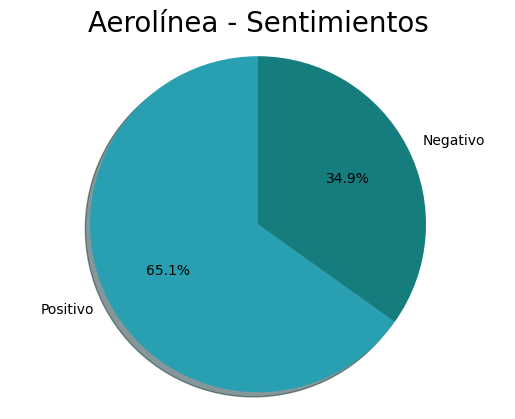

In [ ]:
import matplotlib.pyplot as plt
labels = 'Positivo', 'Negativo'
colors = ['#29A0B1','#167D7F','#98D7C2']
plt.pie(data_cleaned['result'].value_counts(), labels = labels, colors = colors,
        autopct = '%1.1f%%', shadow = True, startangle = 90)
plt.title('Aerolínea - Sentimientos', fontsize = 20)
plt.axis('equal')
plt.show()

In [ ]:
from wordcloud import WordCloud
text = ' '.join(data_cleaned.clean_text)
text

'recently delay British Airways BRU LHR due staff shortages. announced 2 hour holding delay would board us immediately hopes clearing gate leaving early. wait full 2 hours inside airplane. plane old, dirty, power seats. staff provided small bag pretzels 250ml water passengers 2 hour delay 2 hour flight. options purchase food drink. entertainment options available. OneWorld emerald elite member upgrade members based status. First class lounges Heathrow overcrowded, understaffed poorly equipped. help desk completely unhelpful error arises delays cancellations - even top status. Avios points system devalued near worthlessness requires fees book reward nearly equal price revenue ticket. British lost way recent years moved world-class airline budget airline much worse service timeliness Ryanair EasyJet. Angry, disappointed, unsatisfied. route London Atlanta. suitcase boarded, therefore landed me. comfort safety reason, bag always fly passenger happen. Claims phone calls made desk assistants

In [ ]:
wordcloud = WordCloud(width=1024, height=800, colormap='Blues', min_font_size=14).generate(text)

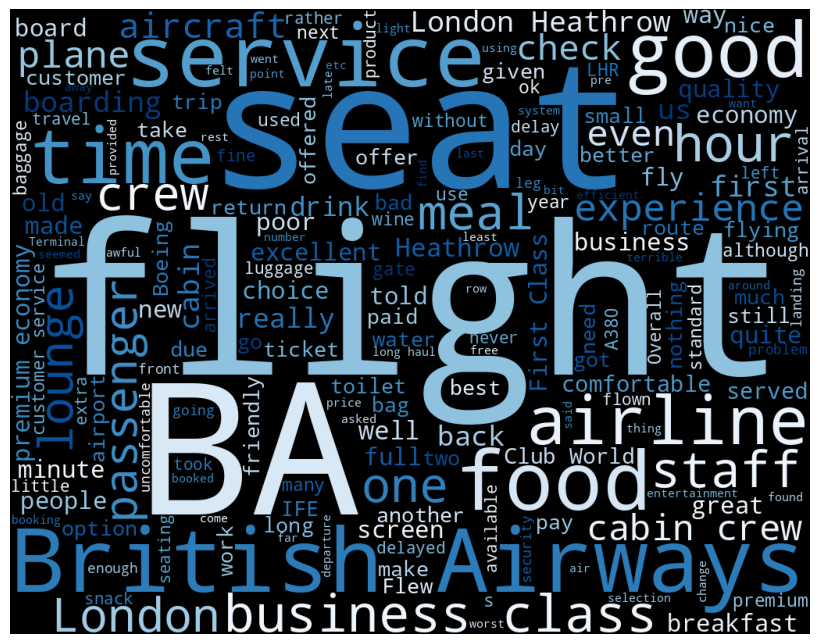

In [ ]:
plt.figure(figsize= (8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis('off')
plt.tight_layout(pad = 0)
plt.show()

## Análisis de clusters

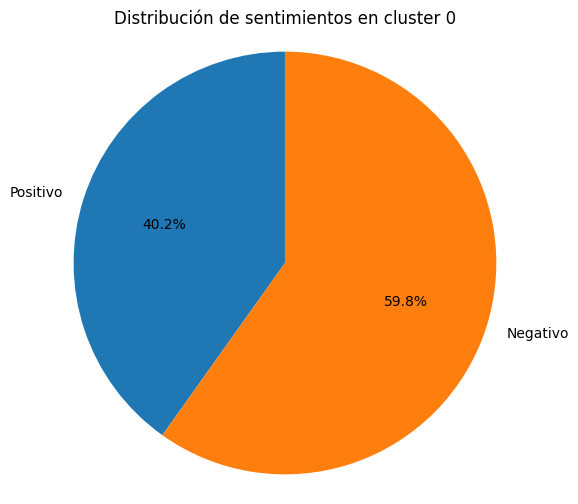

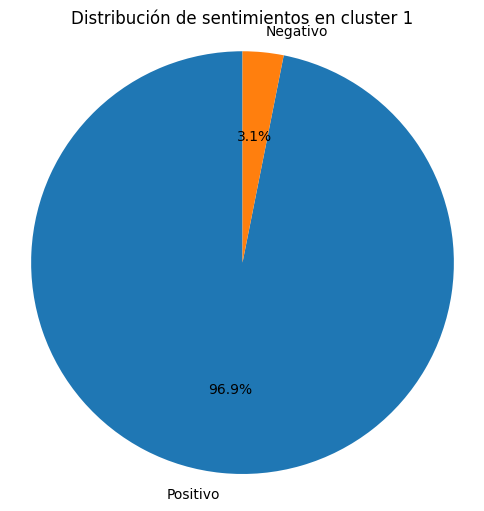

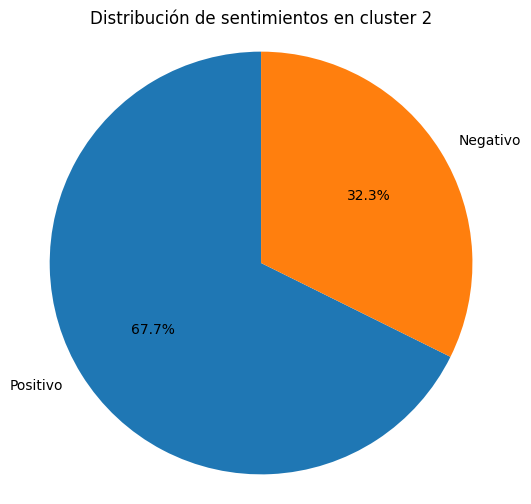

In [ ]:
# Crear el gráfico por cada cluster
for cluster in range(3):
    cluster_data = data_cleaned[data_cleaned['cluster'] == cluster]
    sentiment_counts = cluster_data['result'].value_counts()

    # Verificar si ambos sentimientos existen en el cluster
    if 1 in sentiment_counts and -1 in sentiment_counts:
        labels = ['Positivo', 'Negativo']
        sizes = [sentiment_counts[1], sentiment_counts[-1]]

        plt.figure(figsize=(6, 6))  # Ajustar la figura
        plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
        plt.title(f'Distribución de sentimientos en cluster {cluster}')
        plt.axis('equal')  # Asegura que el gráfico se dibuje como un círculo.
        plt.show()
    else:
        print(f"Cluster {cluster} no tiene sentimientos positivos y negativos.")


In [ ]:
import nltk
from nltk.probability import FreqDist
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

def analyze_cluster_word_frequency(data, cluster_num):
    cluster_data = data_cleaned[data_cleaned['cluster'] == cluster_num]
    positive_reviews = cluster_data[cluster_data['result'] == 1]['ReviewBody']
    negative_reviews = cluster_data[cluster_data['result'] == -1]['ReviewBody']
    stop_words = set(stopwords.words('english'))

    def preprocess_text(text):
        words = word_tokenize(text.lower())
        words = [w for w in words if w.isalnum() and w not in stop_words]  # Remover puntuación y stopwords
        return words


    print(f"\nAnálisis cluster {cluster_num}:")

    if not positive_reviews.empty:
        positive_words = []
        for review in positive_reviews:
          positive_words.extend(preprocess_text(review))
        freq_dist_positive = FreqDist(positive_words)
        print("\nPalabras más frecuentes en comentarios positivos:")
        print(freq_dist_positive.most_common(10))


    else:
        print("\nNo se encontraron sentimientos positivos en el cluster.")

    if not negative_reviews.empty:
        negative_words = []
        for review in negative_reviews:
          negative_words.extend(preprocess_text(review))
        freq_dist_negative = FreqDist(negative_words)
        print("\nPalabras más frecuentes en comentarios negativos:")
        print(freq_dist_negative.most_common(10))  # Print top 10 frequent words

    else:
        print("\nNo se encontraron sentimientos negativos en el cluster.")


for i in range(3):  # Assuming you have 5 clusters
    analyze_cluster_word_frequency(data_cleaned, i)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.



Análisis cluster 0:

Palabras más frecuentes en comentarios positivos:
[('ba', 87), ('flight', 75), ('airways', 53), ('service', 53), ('british', 52), ('class', 45), ('seats', 40), ('seat', 40), ('crew', 36), ('food', 35)]

Palabras más frecuentes en comentarios negativos:
[('flight', 126), ('ba', 95), ('class', 89), ('british', 76), ('airways', 73), ('seat', 69), ('business', 62), ('london', 59), ('service', 59), ('food', 58)]

Análisis cluster 1:

Palabras más frecuentes en comentarios positivos:
[('flight', 151), ('good', 115), ('ba', 81), ('service', 76), ('food', 76), ('crew', 73), ('cabin', 59), ('club', 51), ('london', 49), ('lounge', 48)]

Palabras más frecuentes en comentarios negativos:
[('flight', 8), ('british', 5), ('airways', 5), ('lounge', 5), ('return', 5), ('due', 4), ('us', 4), ('class', 3), ('first', 3), ('ba', 3)]

Análisis cluster 2:

Palabras más frecuentes en comentarios positivos:
[('flight', 111), ('ba', 96), ('london', 54), ('airways', 52), ('crew', 51), ('cl

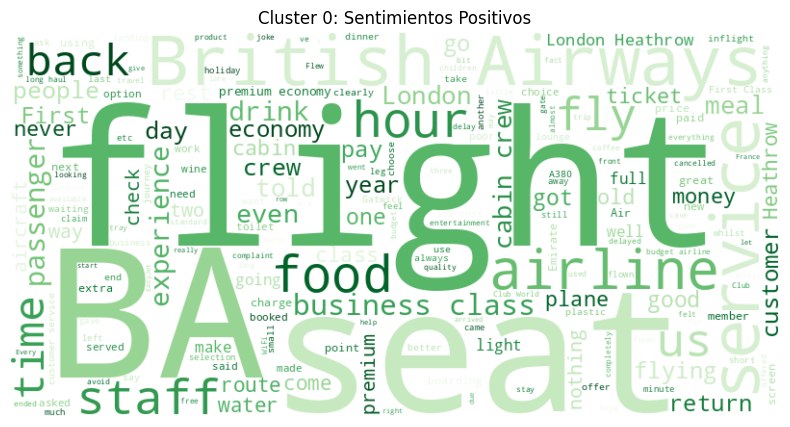

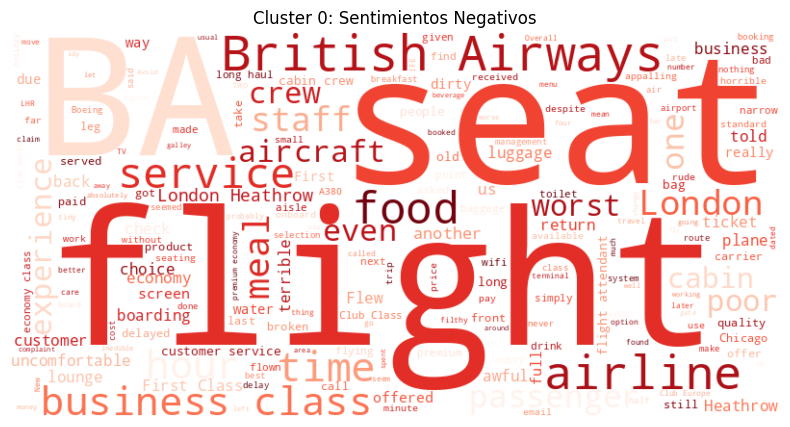

--------------------------------------------------


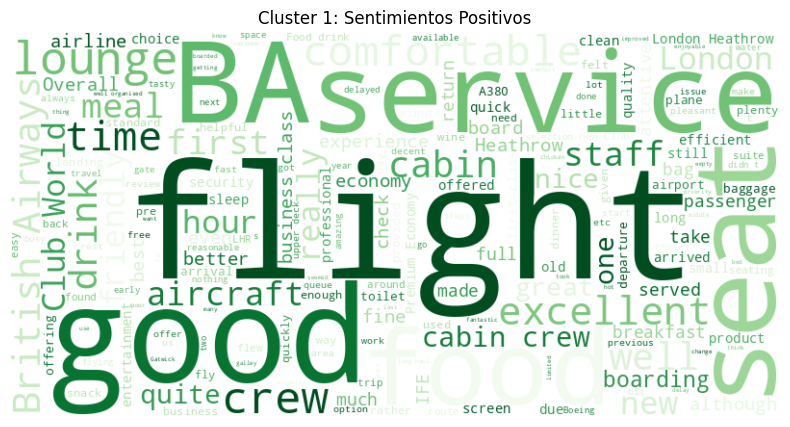

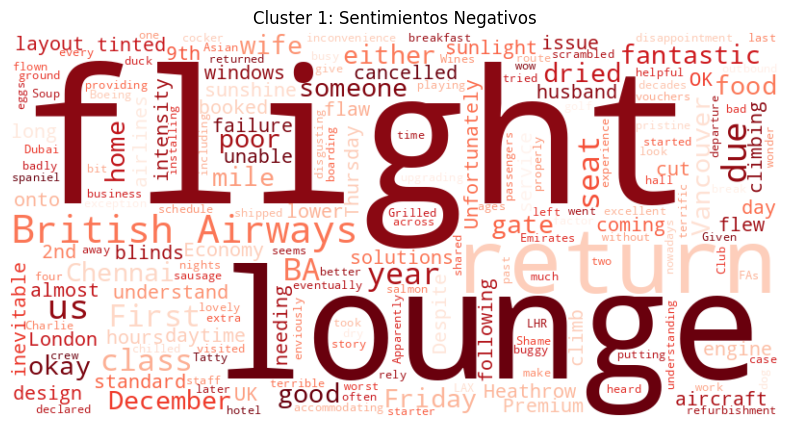

--------------------------------------------------


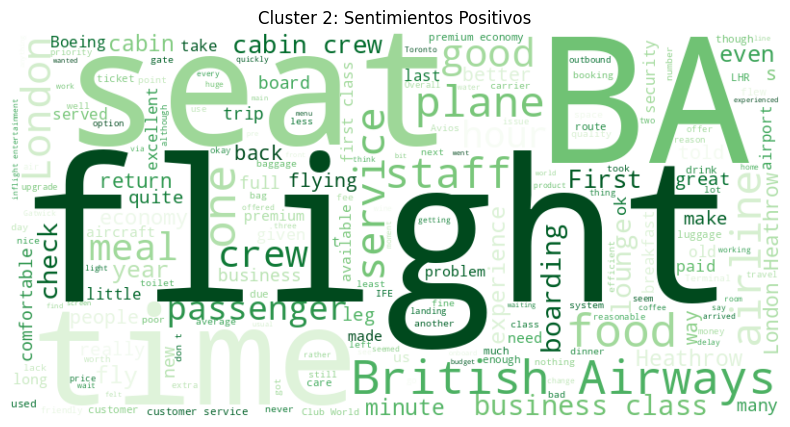

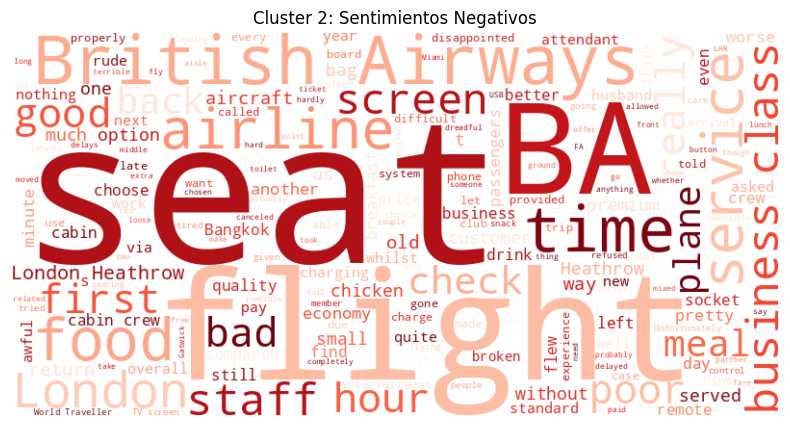

--------------------------------------------------


In [ ]:

# Generar wordclouds por sentimiento para cada cluster
for cluster_id in range(data_cleaned['cluster'].nunique()):
    cluster_data = data_cleaned[data_cleaned['cluster'] == cluster_id]

    # Wordcloud para sentimientos positivos
    positive_text = ' '.join(cluster_data[cluster_data['result'] == 1]['clean_text'])
    if positive_text:
        wordcloud_pos = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(positive_text)
        plt.figure(figsize=(10, 5))
        plt.imshow(wordcloud_pos, interpolation='bilinear')
        plt.axis('off')
        plt.title(f'Cluster {cluster_id}: Sentimientos Positivos')
        plt.show()
    else:
        print(f"Cluster {cluster_id} no tiene texto positivo.")

    # Wordcloud para sentimientos negativos
    negative_text = ' '.join(cluster_data[cluster_data['result'] == -1]['clean_text'])
    if negative_text:
        wordcloud_neg = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(negative_text)
        plt.figure(figsize=(10, 5))
        plt.imshow(wordcloud_neg, interpolation='bilinear')
        plt.axis('off')
        plt.title(f'Cluster {cluster_id}: Sentimientos Negativos')
        plt.show()
    else:
        print(f"Cluster {cluster_id} no tiene texto negativo.")

    print("-" * 50) # Separador entre clusters


---

## 📊 Informe Ejecutivo: Análisis de Sentimientos en Comentarios de Clientes hacia la Aerolínea

### 📌 Resumen General

Se ha realizado un análisis de clústeres sobre comentarios de clientes para identificar las principales razones de satisfacción e insatisfacción con la aerolínea. A través del análisis de nubes de palabras y las frecuencias de términos más comunes, se destacan los siguientes hallazgos:

---

### 🔎 Cluster 0:

#### ✈️ Comentarios Positivos

* Las palabras más frecuentes incluyen: **'BA', 'flight', 'airways', 'service', 'seats', 'seat', 'food'**.
* Los clientes valoran principalmente:

  * Buen servicio durante el vuelo.
  * Comodidad y calidad de los asientos.
  * Experiencias agradables con la comida y la atención.

#### ⚠️ Comentarios Negativos

* Las palabras más frecuentes incluyen: **'flight', 'ba', 'class', 'seats', 'seat', 'business', 'service', 'food'**.
* Las principales razones de insatisfacción:

  * Incomodidad en los asientos y espacio insuficiente.
  * Problemas con el servicio, tanto en tierra como a bordo.
  * Quejas sobre la calidad de la comida y de las cabinas de clase ejecutiva.

---

### 🔎 Cluster 1:

#### ✈️ Comentarios Positivos

* Palabras clave: **'flight', 'good', 'ba', 'service', 'food', 'crew', 'cabin', 'club', 'london'**.
* Razones de satisfacción:

  * Excelente servicio por parte del personal.
  * Comodidad de cabinas y buena atención.
  * Experiencia positiva en áreas como Club World y London lounge.

#### ⚠️ Comentarios Negativos

* Palabras clave: **'flight', 'british', 'airways', 'lounge', 'return', 'due', 'us', 'class'**.
* Motivos de insatisfacción:

  * Demoras en los vuelos y problemas con el regreso.
  * Inconvenientes en las salas VIP (lounge).
  * Fallos de servicio en cabina y a bordo.

---

### 🔎 Cluster 2:

#### ✈️ Comentarios Positivos

* Palabras clave: **'flight', 'ba', 'london', 'airways', 'service', 'crew', 'class', 'food', 'time'**.
* Satisfacción destacada por:

  * Experiencia de vuelo agradable y eficiente.
  * Personal de cabina y servicio atento.
  * Buenas condiciones generales del viaje.

#### ⚠️ Comentarios Negativos

* Palabras clave: **'flight', 'ba', 'seat', 'london', 'british', 'airways', 'would', 'seats', 'business', 'heathrow'**.
* Razones principales de insatisfacción:

  * Asientos incómodos y limitados en espacio.
  * Problemas con el embarque en Heathrow.
  * Deficiencias en la calidad del servicio y atención al cliente.

---

### 📝 Conclusiones:

* Los clientes están generalmente **satisfechos con el servicio y la experiencia general**, destacando el trato del personal, la calidad del servicio a bordo, y la comodidad en cabinas superiores.
* **Las principales quejas** giran en torno a:

  * **Asientos incómodos** o insuficientes.
  * **Problemas con el servicio al cliente**, tanto en vuelo como en tierra.
  * **Deficiencias en la calidad de la comida y el servicio**, especialmente en clase ejecutiva.
  * **Demoras o inconvenientes en el regreso y embarque**.

---

### 📈 Recomendaciones:

1️⃣ Mejorar la **calidad y comodidad de los asientos**, especialmente en clase económica y ejecutiva.
2️⃣ Capacitar aún más al **personal de cabina y de tierra** para ofrecer un servicio más ágil y resolutivo.
3️⃣ Revisar y mejorar el **servicio de comidas y bebidas** para superar expectativas.
4️⃣ Optimizar la **experiencia en salas VIP (lounge)** y resolver problemas de embarque.
